# Financial Modelling
## Preliminary Analysis

In [1]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from modules.finance.exploration import *

plt.rcParams.update({"font.size": 14})
pd.set_option("display.max_columns", None)

DATA_DIR = "./data/"
OUTPUT_DIR = "./data/"

FINANCIAL_PANEL_FILE = OUTPUT_DIR + "financial_returns_and_controls.parquet"
EPI_DATA_FILE = OUTPUT_DIR + "epi_data.json"
RETURNS_EPI_FILE = OUTPUT_DIR + "financial_returns_with_epi.parquet"

## 1. Import Data

In [2]:
# FINANCIAL PANEL DATA
df_returns = pd.read_parquet(FINANCIAL_PANEL_FILE)
print("Financial panel data loaded:")
print(f"Columns: {df_returns.columns.tolist()}")
print(f"Date range: {df_returns.index.min()} to {df_returns.index.max()}")
print(df_returns.head())

Financial panel data loaded:
Columns: ['r_btc', 'r_gold', 'r_spx', 'dln_eurusd', 'dln_usdcny', 'dln_oil', 'dy10']
Date range: 2025-01-01 00:00:00 to 2025-05-30 00:00:00
               r_btc    r_gold     r_spx  dln_eurusd  dln_usdcny   dln_oil  \
2025-01-01  0.010546  0.000000  0.000000    0.000000    0.000000  0.000000   
2025-01-02  0.025794  0.011233 -0.002226    0.005231    0.000000  0.019469   
2025-01-03  0.012519 -0.005241  0.012517    0.008114    0.000069  0.011286   
2025-01-06  0.039675 -0.002498  0.005523   -0.003611    0.002873 -0.005423   
2025-01-07 -0.051824  0.006912 -0.011166   -0.007832    0.000369  0.009336   

             dy10  
2025-01-01  0.000  
2025-01-02  0.002  
2025-01-03  0.021  
2025-01-06  0.022  
2025-01-07  0.065  


In [3]:
# EPI DATA
df_epi = pd.read_json(EPI_DATA_FILE)
df_epi['date'] = pd.to_datetime(df_epi['date'])
df_epi = df_epi.set_index('date')

print("EPI data loaded:")
print(f"Columns: {df_epi.columns.tolist()}")
print(f"Date range: {df_epi.index.min()} to {df_epi.index.max()}")
print(df_epi.head())

EPI data loaded:
Columns: ['ei_creator', 'ei_community', 'epi', 'epi_weighted', 'ei_creator_Disputes and Opinions', 'ei_creator_Leadership and Governance', 'ei_creator_Sports and Recreation', 'ei_creator_Quality of Life and Standards', 'ei_creator_Conspiracy and Historical Events', 'ei_creator_Security and Conflict', 'ei_creator_Trust, Credibility, and Communication', 'ei_creator_Miscellaneous and Other', 'ei_creator_Labor and Workforce', 'ei_creator_Power and Influence Dynamics', 'ei_creator_Economic and Financial Matters', 'ei_creator_Disaster and Resilience', 'ei_creator_Social and Cultural Aspects', 'ei_creator_Health and Social Welfare', 'ei_creator_Legal and Regulatory Framework', 'ei_creator_Environmental and Infrastructure', 'ei_creator_Psychological and Emotional Aspects', 'ei_creator_Education and Knowledge', 'ei_community_Disputes and Opinions', 'ei_community_Leadership and Governance', 'ei_community_Sports and Recreation', 'ei_community_Quality of Life and Standards', 'ei_c

In [4]:
# Merge on index (date)
df_returns = df_returns.join(df_epi, how='left')

# Fill missing EPI values with 0 (neutral) for dates without EPI data
df_returns[df_epi.columns] = df_returns[df_epi.columns].fillna(0)

print("Returns with EPI data:")
print(f"Shape: {df_returns.shape}")
print(f"Columns: {df_returns.columns.tolist()}")
print(df_returns.head())

Returns with EPI data:
Shape: (108, 67)
Columns: ['r_btc', 'r_gold', 'r_spx', 'dln_eurusd', 'dln_usdcny', 'dln_oil', 'dy10', 'ei_creator', 'ei_community', 'epi', 'epi_weighted', 'ei_creator_Disputes and Opinions', 'ei_creator_Leadership and Governance', 'ei_creator_Sports and Recreation', 'ei_creator_Quality of Life and Standards', 'ei_creator_Conspiracy and Historical Events', 'ei_creator_Security and Conflict', 'ei_creator_Trust, Credibility, and Communication', 'ei_creator_Miscellaneous and Other', 'ei_creator_Labor and Workforce', 'ei_creator_Power and Influence Dynamics', 'ei_creator_Economic and Financial Matters', 'ei_creator_Disaster and Resilience', 'ei_creator_Social and Cultural Aspects', 'ei_creator_Health and Social Welfare', 'ei_creator_Legal and Regulatory Framework', 'ei_creator_Environmental and Infrastructure', 'ei_creator_Psychological and Emotional Aspects', 'ei_creator_Education and Knowledge', 'ei_community_Disputes and Opinions', 'ei_community_Leadership and Gove

In [5]:
# Save as parquet
df_returns.to_parquet(RETURNS_EPI_FILE)
print("Saved financial returns with EPI data to parquet.")

Saved financial returns with EPI data to parquet.


## 2. Analyse

In [6]:
OUTDIR = "data/fm_prelim/"
SAVE_FIGS = False  # set True if you want png/csv outputs as well
ROLLING_WINDOW = 14
ACF_LAGS = 10
MAX_LAG = 10
PCA_COMPONENTS = 5

os.makedirs(OUTDIR, exist_ok=True)

In [7]:
# Column selections
df1 = df_returns.copy()
market_cols = ["r_btc", "r_gold", "r_spx", "dln_eurusd", "dln_usdcny", "dln_oil", "dy10"]
agg_cols = ["ei_creator", "ei_community", "epi", "epi_weighted", "ei_creator_weighted", "ei_community_weighted"]

market_cols = [c for c in market_cols if c in df1.columns]
agg_cols = [c for c in agg_cols if c in df1.columns]

df1 = safe_numeric(df1, market_cols + agg_cols)

ei_creator_topics = find_topic_cols(df1.columns, "ei_creator")
ei_community_topics = find_topic_cols(df1.columns, "ei_community")
epi_topics = find_topic_cols(df1.columns, "epi")

### Sanity Stats

In [8]:
if market_cols:
    display(describe_block(df1, market_cols))
    savecsv(describe_block(df1, market_cols), os.path.join(OUTDIR, "describe_market.csv"))

if agg_cols:
    display(describe_block(df1, agg_cols))
    savecsv(describe_block(df1, agg_cols), os.path.join(OUTDIR, "describe_aggregate.csv"))

missing = (df1.isna().mean() * 100).sort_values(ascending=False).to_frame("missing_pct")
display(missing.head(30))
savecsv(missing, os.path.join(OUTDIR, "missingness_all.csv"))

,count,mean,std,min,25%,50%,75%,max,skew,kurt,missing_pct,zero_pct
dln_eurusd,108.0,-0.000827,0.006240,-0.027537,-0.004166,0.000345,0.002596,0.014482,-0.786040,2.629217,0.0,2.777778
dln_oil,108.0,-0.001531,0.019961,-0.076973,-0.015263,0.000000,0.009615,0.045444,-0.621407,1.852744,0.0,4.629630
dln_usdcny,108.0,-0.000121,0.002572,-0.011263,-0.000310,0.000000,0.000655,0.012261,-0.207428,7.688474,0.0,24.074074
dy10,108.0,-0.001454,0.060005,-0.141000,-0.043000,0.000000,0.034000,0.170000,0.063488,0.098667,0.0,5.555556
r_btc,108.0,0.000992,0.027985,-0.099440,-0.016580,0.001624,0.017573,0.079389,-0.132456,1.154557,0.0,0.000000
r_gold,108.0,0.002073,0.013277,-0.037296,-0.004168,0.002444,0.009006,0.032973,-0.343512,0.845706,0.0,4.629630
r_spx,108.0,0.000047,0.016063,-0.061609,-0.005191,0.000732,0.006308,0.090895,0.830267,10.986482,0.0,5.555556


,count,mean,std,min,25%,50%,75%,max,skew,kurt,missing_pct,zero_pct
ei_community,108.0,-0.250555,0.116919,-0.439997,-0.318640,-0.275798,-0.214874,0.247619,1.713253,3.927617,0.0,3.703704
ei_community_weighted,108.0,-0.212312,0.229843,-0.752797,-0.381959,-0.223133,-0.061984,0.690723,0.881561,1.842579,0.0,3.703704
ei_creator,108.0,-0.066383,0.283907,-1.000000,-0.196739,-0.090581,0.004098,1.000000,0.197958,3.109554,0.0,13.888889
ei_creator_weighted,108.0,-0.062277,0.517819,-1.000000,-0.362600,-0.025989,0.316378,1.000000,0.146781,-0.435638,0.0,10.185185
epi,108.0,-0.359315,0.260425,-1.000000,-0.535362,-0.331840,-0.160838,0.008609,-0.628001,-0.247400,0.0,1.851852
epi_weighted,108.0,-0.498938,0.272579,-1.000000,-0.714334,-0.500420,-0.278903,0.115873,0.154159,-0.858496,0.0,1.851852


,missing_pct
r_btc,0.0
epi_Quality of Life and Standards,0.0
ei_community_Miscellaneous and Other,0.0
ei_community_Labor and Workforce,0.0
ei_community_Power and Influence Dynamics,0.0
ei_community_Economic and Financial Matters,0.0
ei_community_Disaster and Resilience,0.0
ei_community_Social and Cultural Aspects,0.0
ei_community_Health and Social Welfare,0.0
ei_community_Legal and Regulatory Framework,0.0


### Rolling mean/std (aggregate EI/EPI)

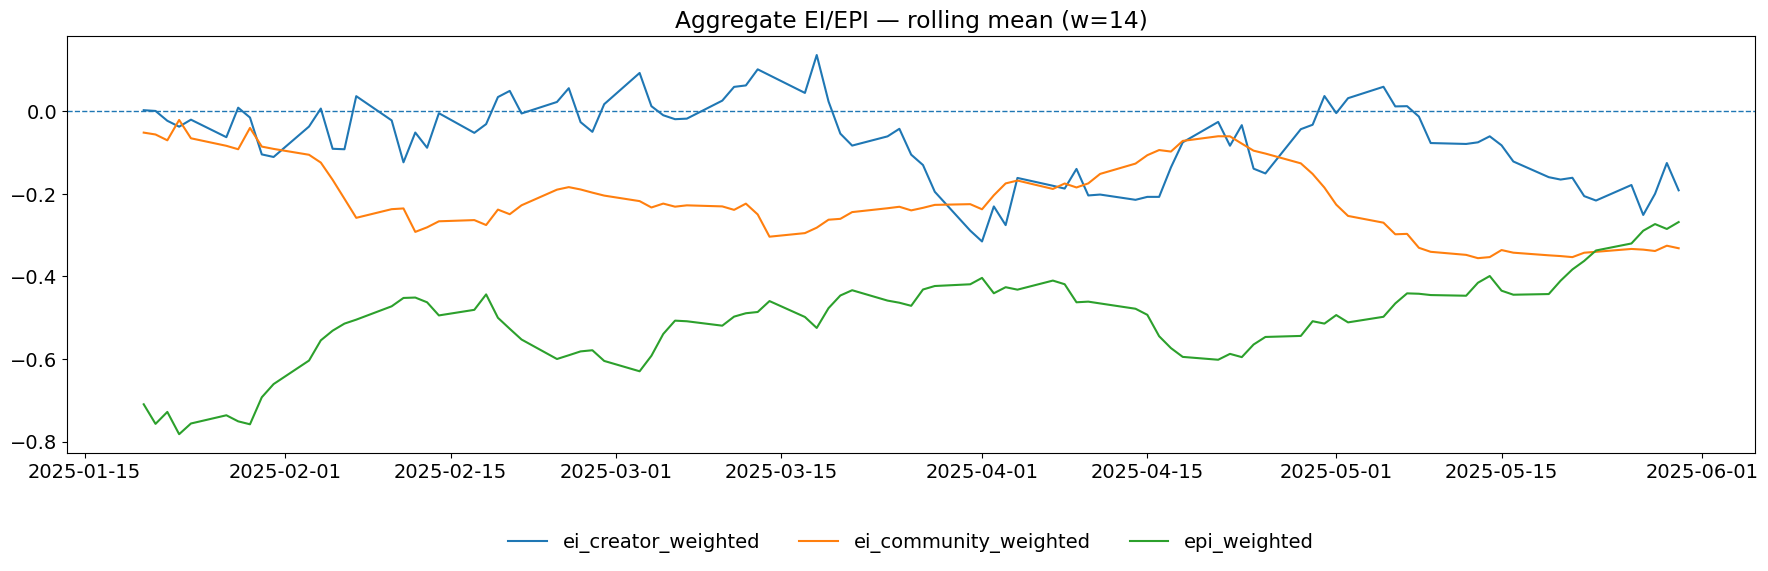

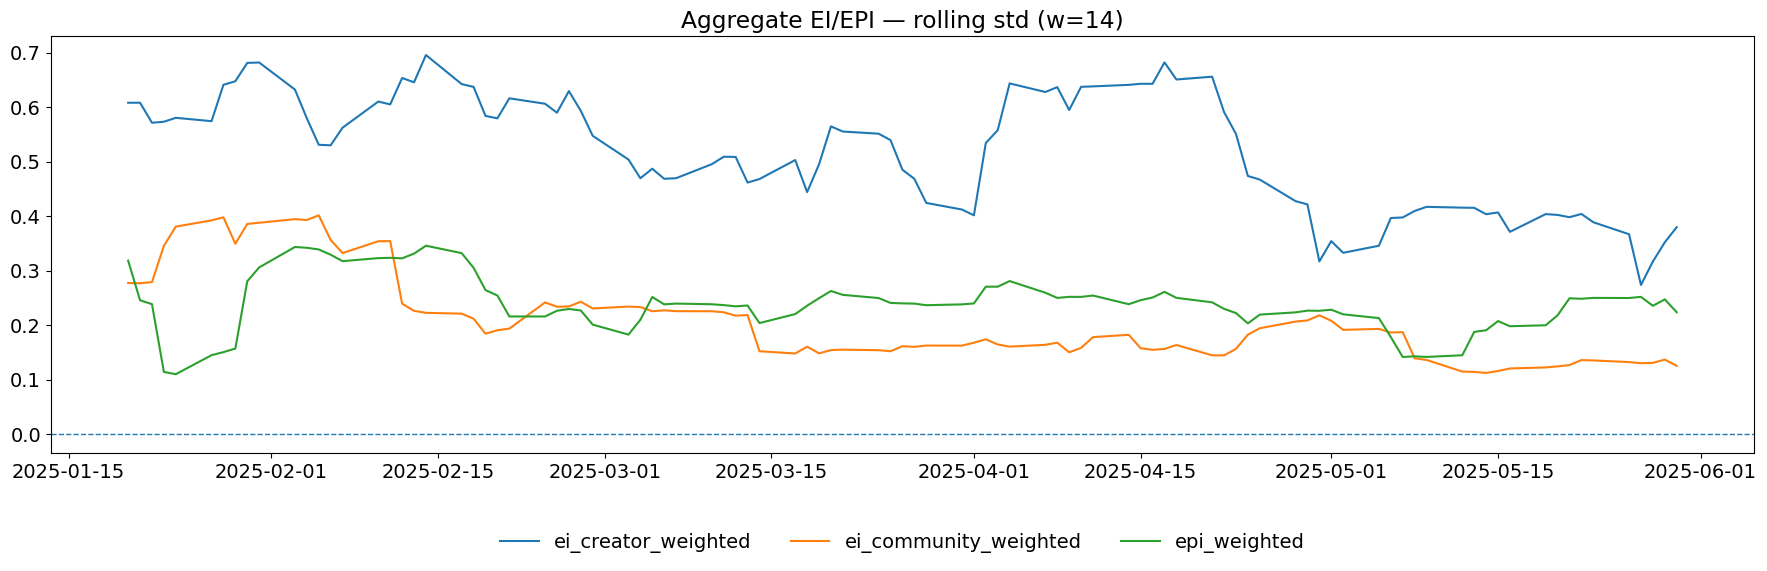

In [9]:
plot_cols = [c for c in ["ei_creator_weighted", "ei_community_weighted", "epi_weighted"] if c in df1.columns]
if plot_cols:
    rolling_mean_std_plot(df1, plot_cols, ROLLING_WINDOW, "Aggregate EI/EPI")

### ACF (aggregate)

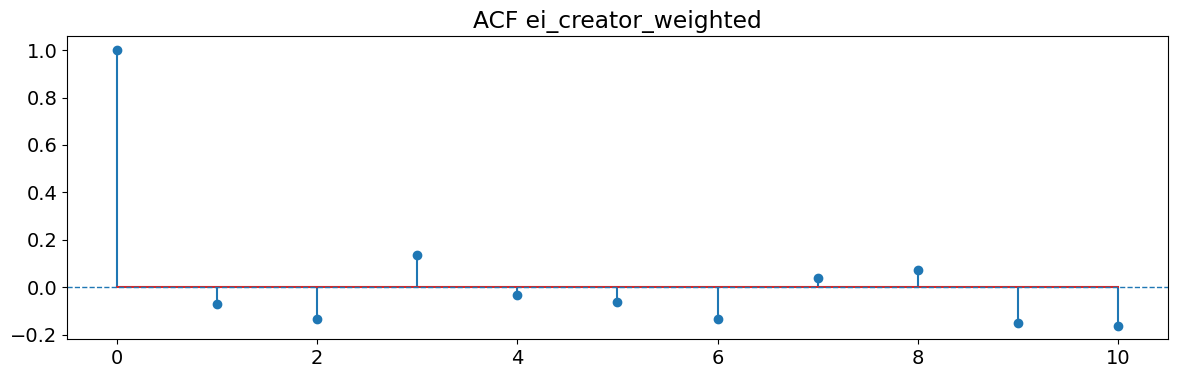

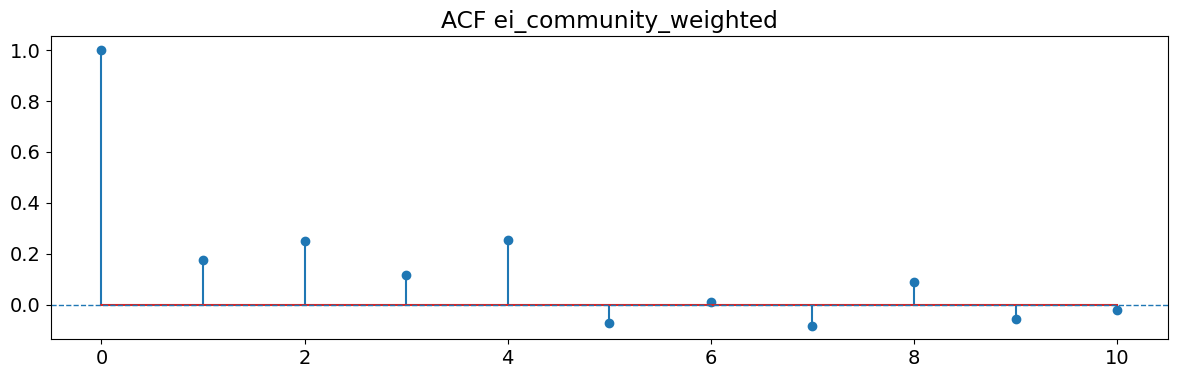

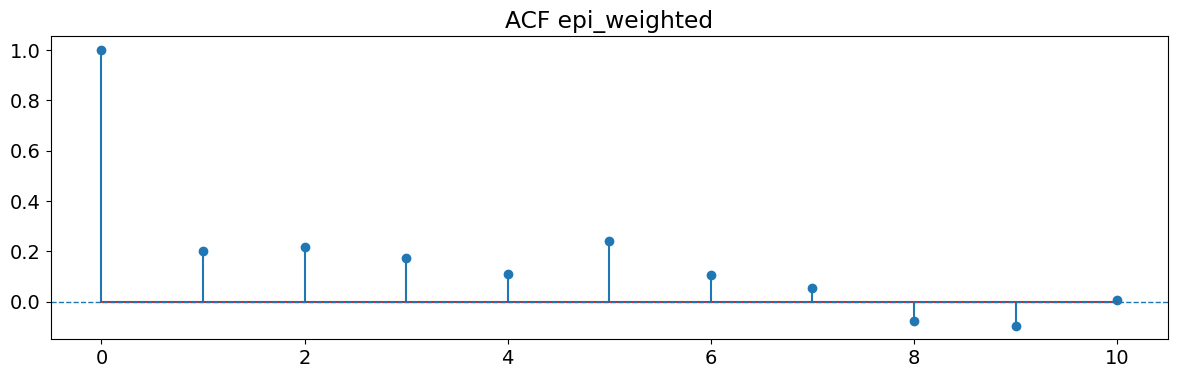

In [10]:
for c in plot_cols:
    acf_plot(df1[c], ACF_LAGS, f"ACF {c}")

### Correlations (aggregate + markets)

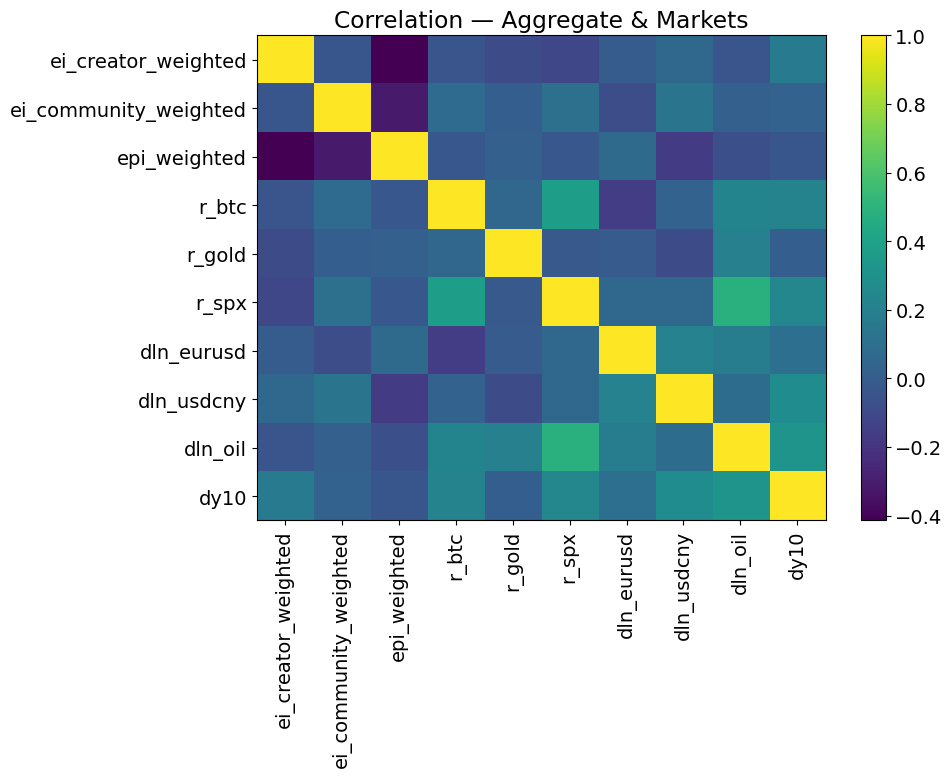

,ei_creator_weighted,ei_community_weighted,epi_weighted,r_btc,r_gold,r_spx,dln_eurusd,dln_usdcny,dln_oil,dy10
ei_creator_weighted,1.000000,-0.035845,-0.413634,-0.042575,-0.087998,-0.110339,-0.003020,0.059431,-0.041389,0.170541
ei_community_weighted,-0.035845,1.000000,-0.314085,0.082395,0.009494,0.105972,-0.080229,0.128704,0.017252,0.028189
epi_weighted,-0.413634,-0.314085,1.000000,-0.030870,0.017917,-0.028793,0.076904,-0.167672,-0.071094,-0.033405
r_btc,-0.042575,0.082395,-0.030870,1.000000,0.050396,0.379632,-0.154737,0.030421,0.226733,0.219848
r_gold,-0.087998,0.009494,0.017917,0.050396,1.000000,-0.017742,-0.005605,-0.083243,0.199584,0.010842
r_spx,-0.110339,0.105972,-0.028793,0.379632,-0.017742,1.000000,0.057356,0.056265,0.485567,0.238235
dln_eurusd,-0.003020,-0.080229,0.076904,-0.154737,-0.005605,0.057356,1.000000,0.215804,0.180600,0.100006
dln_usdcny,0.059431,0.128704,-0.167672,0.030421,-0.083243,0.056265,0.215804,1.000000,0.087818,0.276053
dln_oil,-0.041389,0.017252,-0.071094,0.226733,0.199584,0.485567,0.180600,0.087818,1.000000,0.318916
dy10,0.170541,0.028189,-0.033405,0.219848,0.010842,0.238235,0.100006,0.276053,0.318916,1.000000


In [11]:
corr_cols = [c for c in (plot_cols + market_cols) if c in df1.columns]
if len(corr_cols) >= 3:
    corr = corr_heatmap(df1, corr_cols, "Correlation — Aggregate & Markets")
    display(corr)
    savecsv(corr, os.path.join(OUTDIR, "corr_aggregate_markets.csv"))

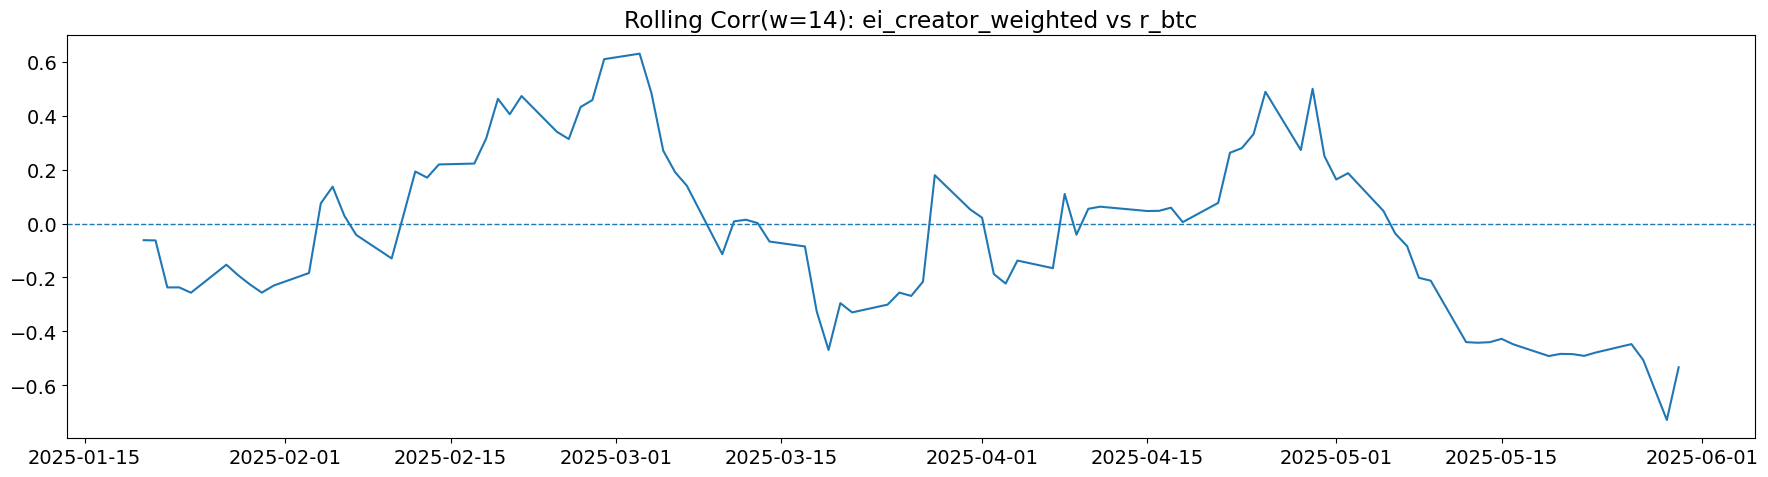

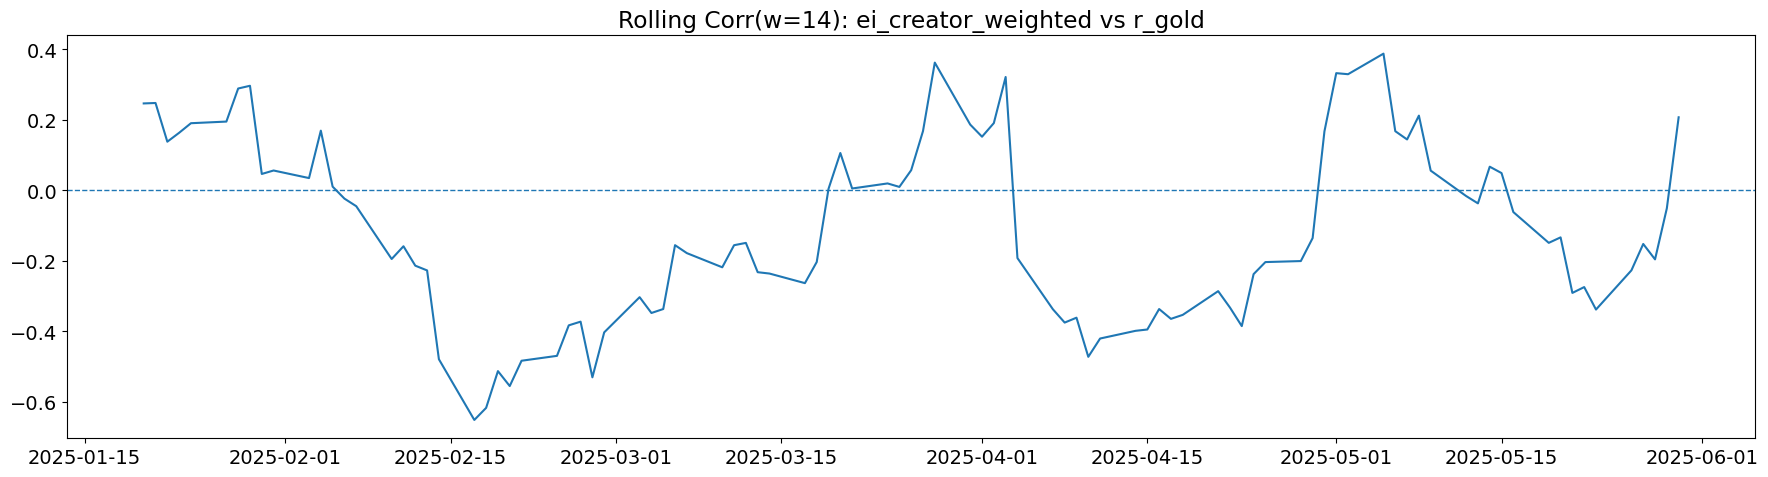

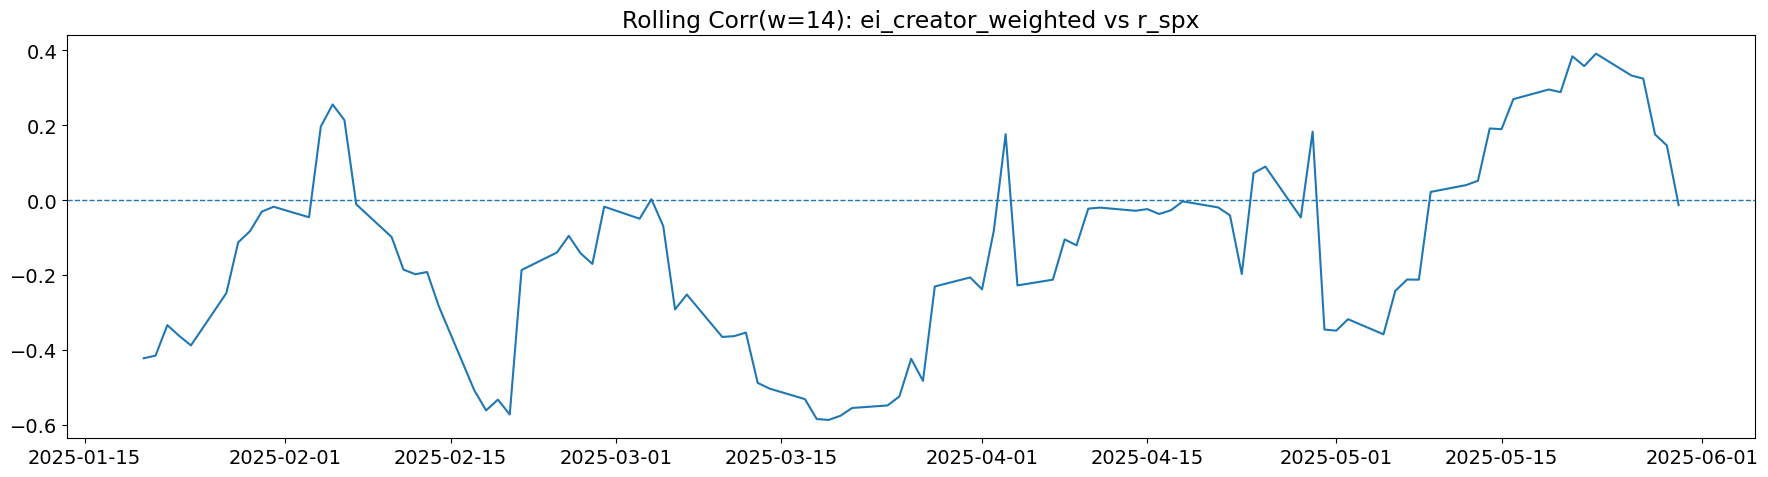

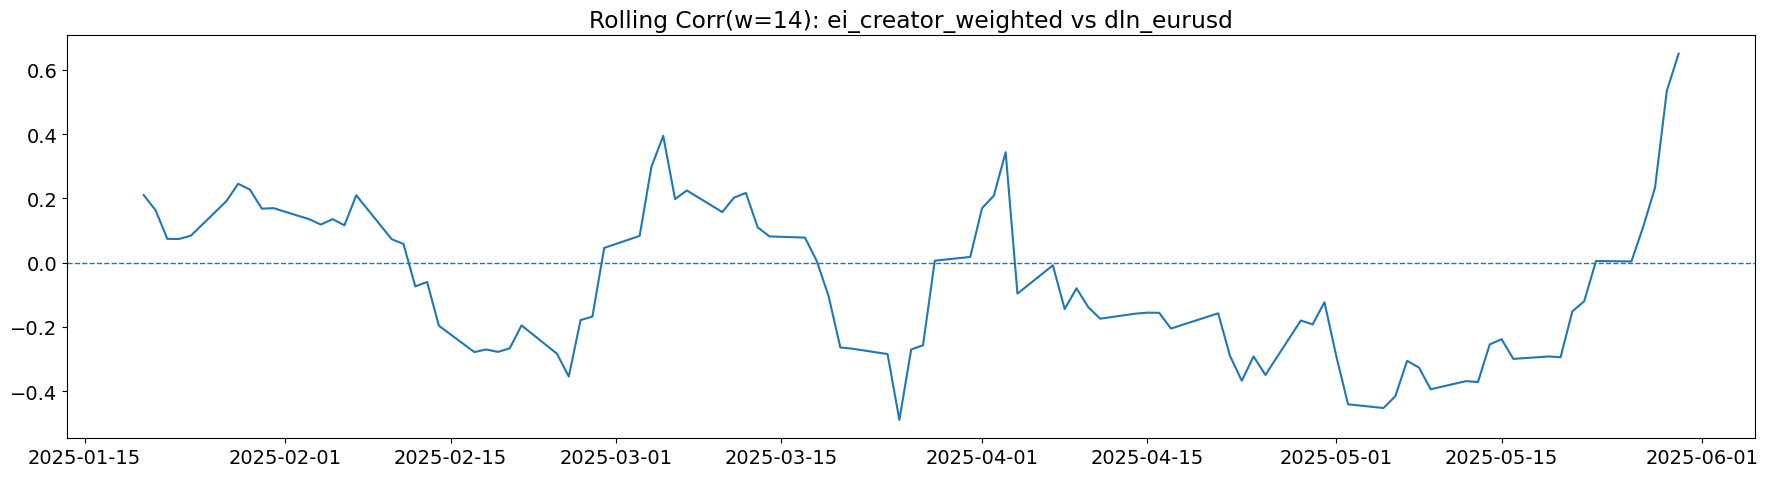

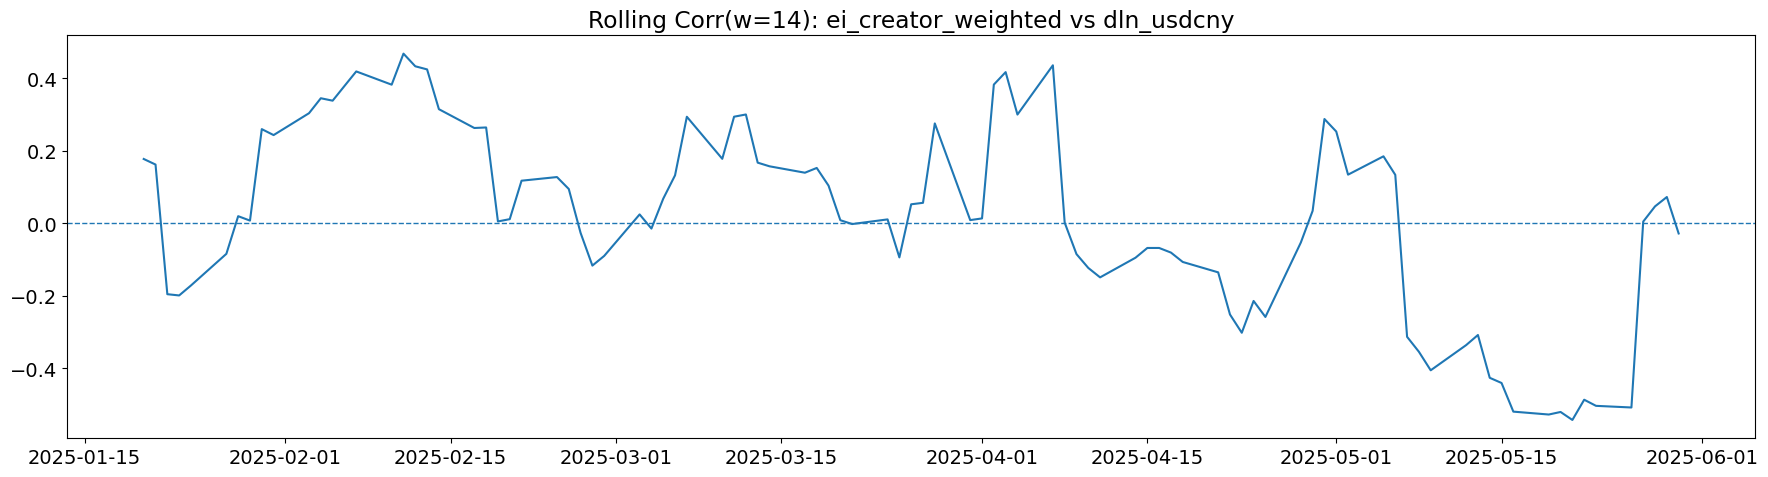

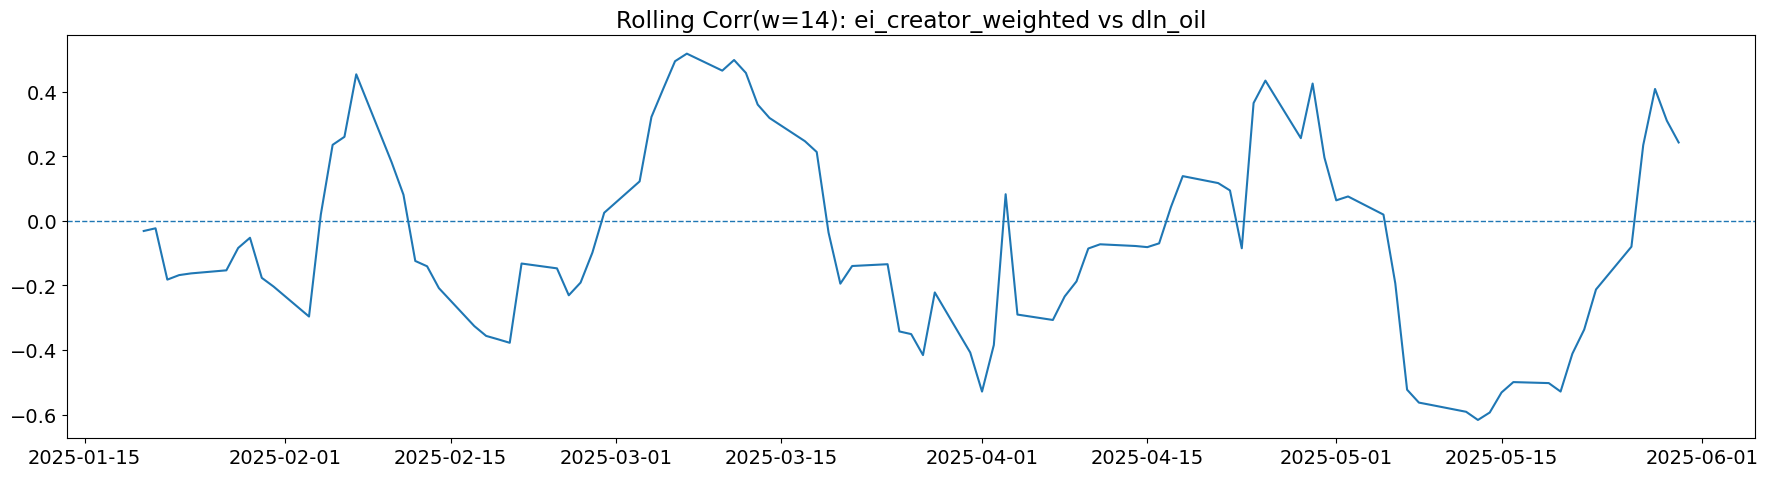

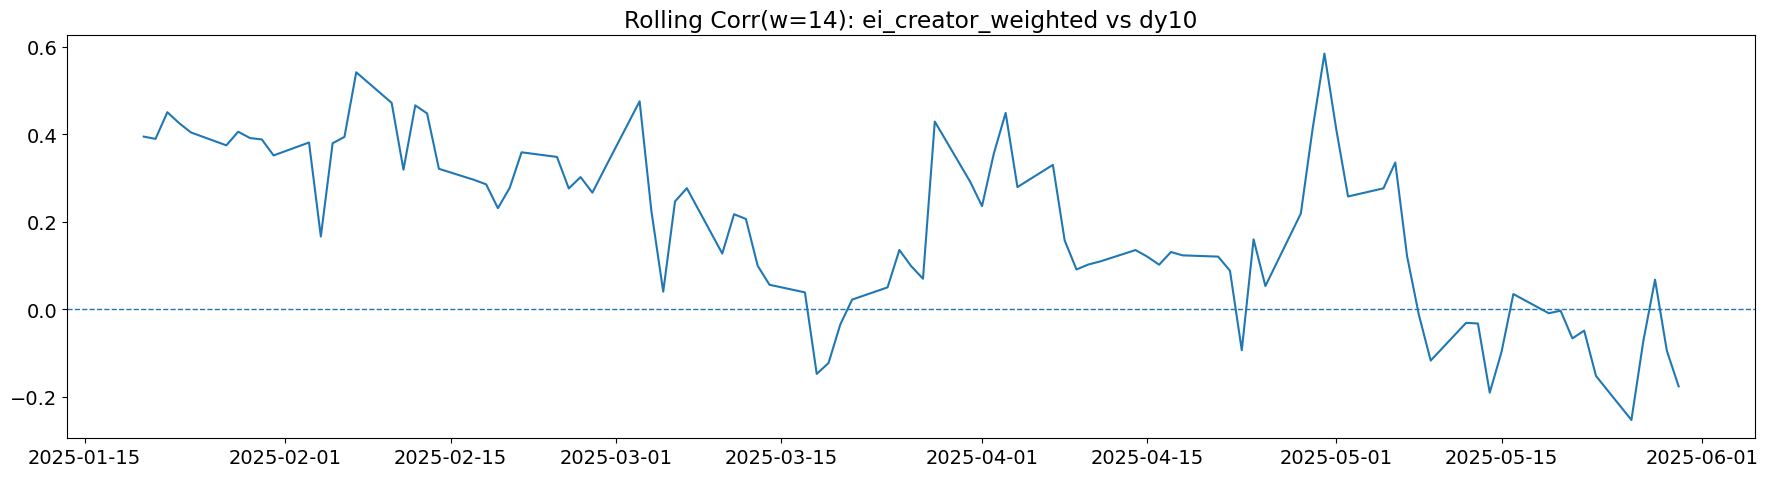

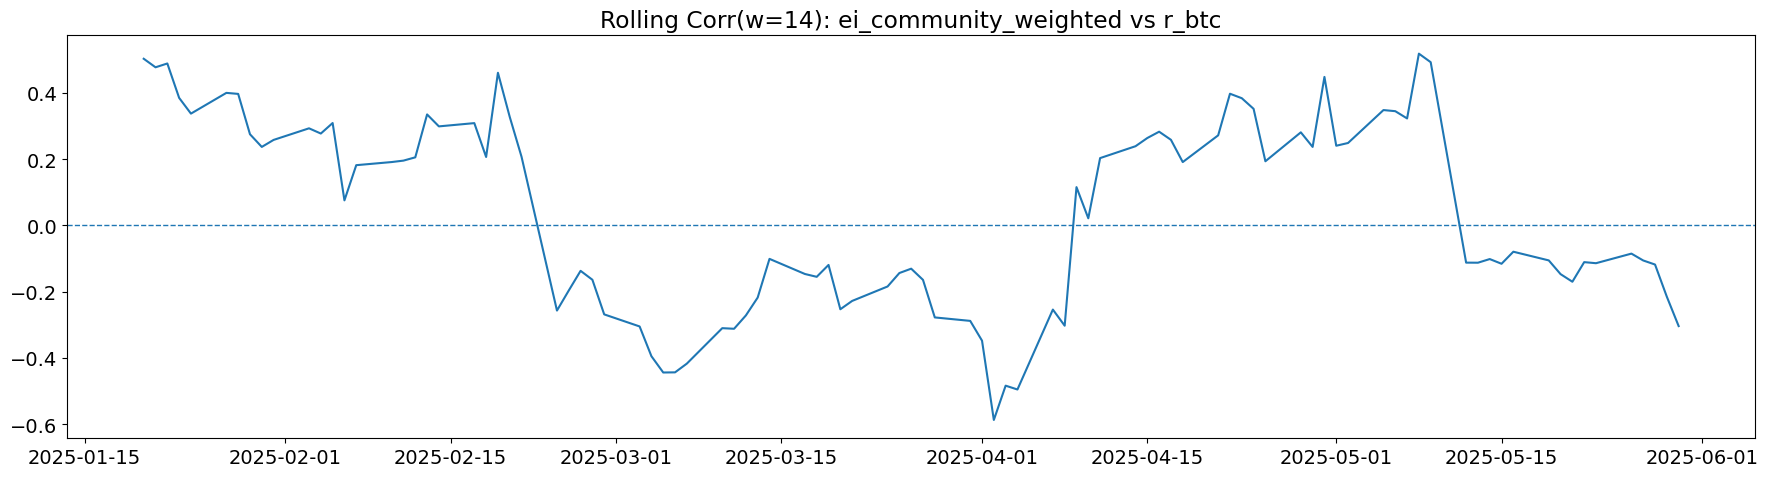

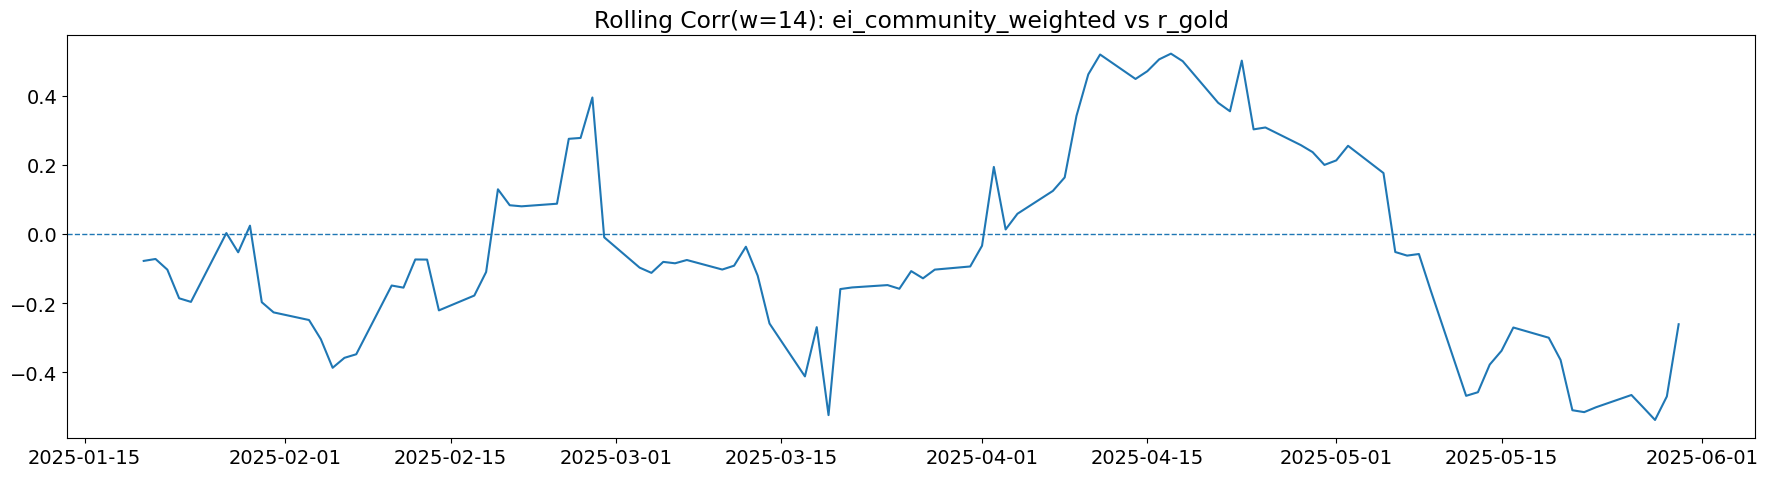

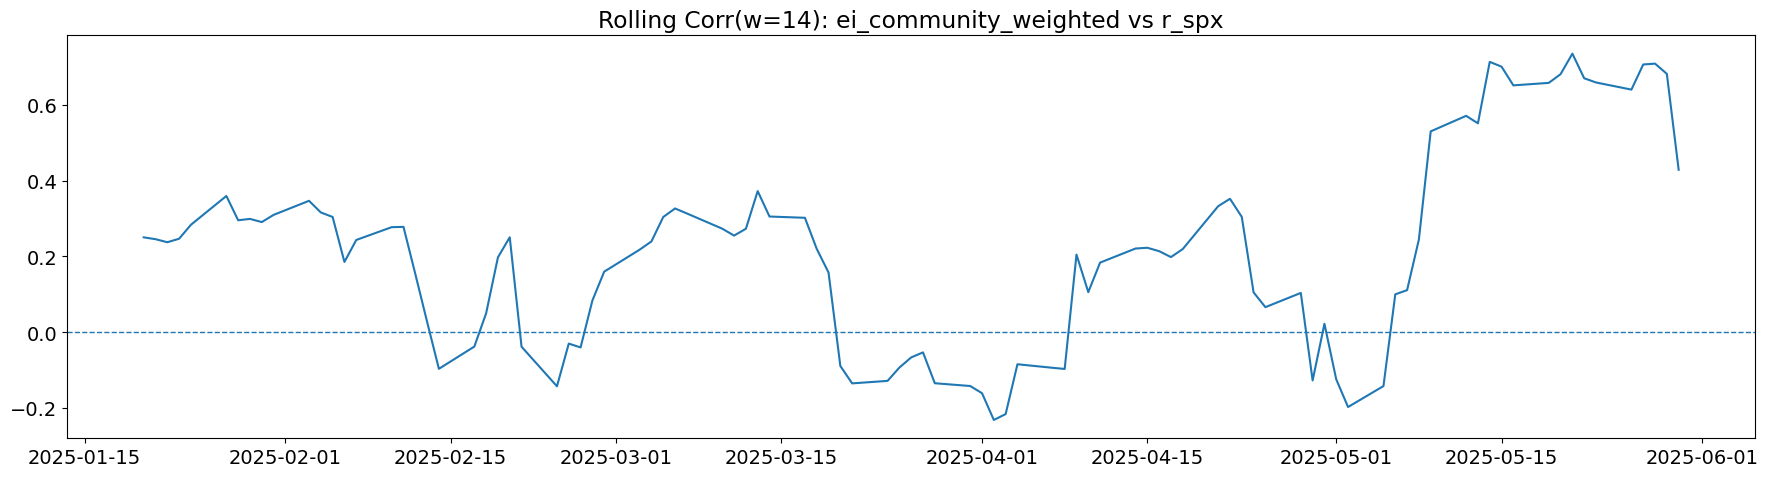

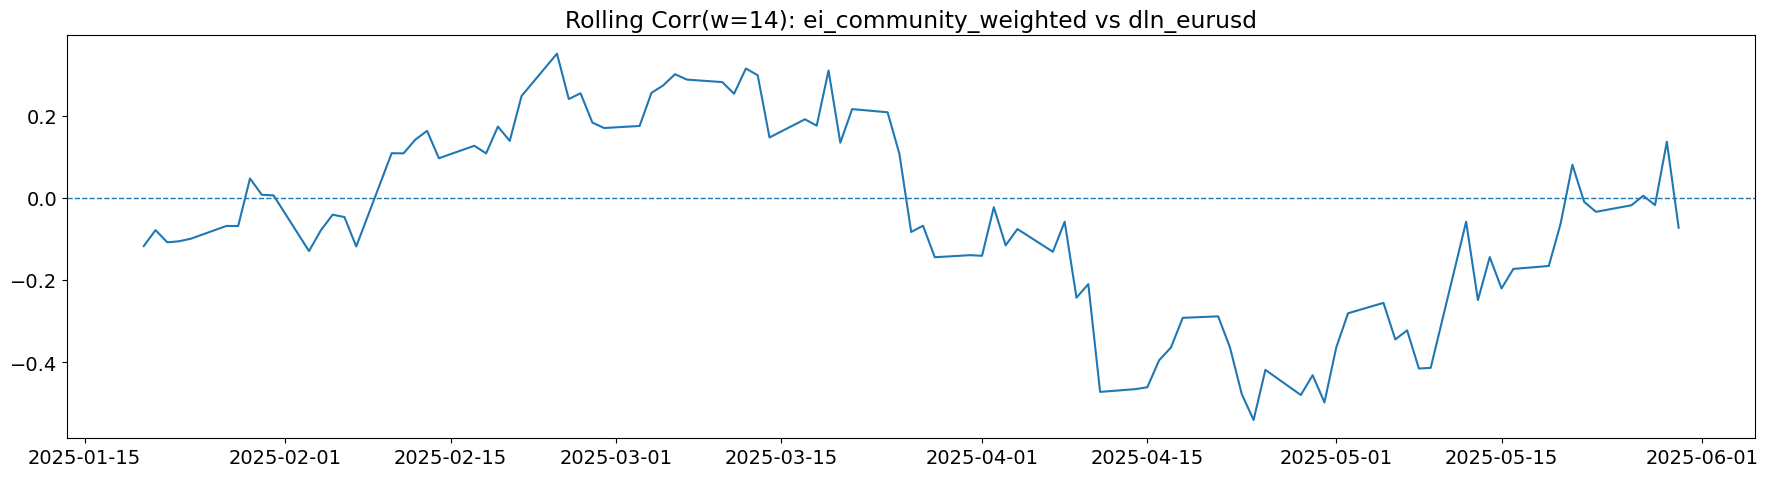

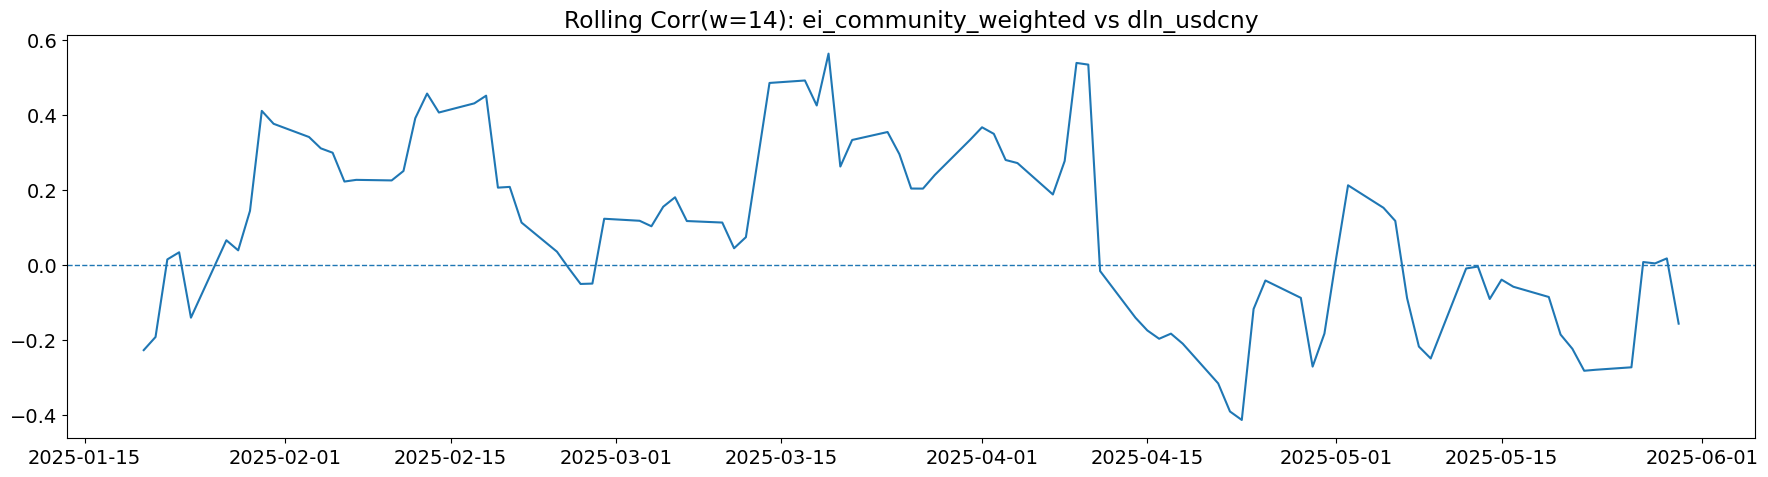

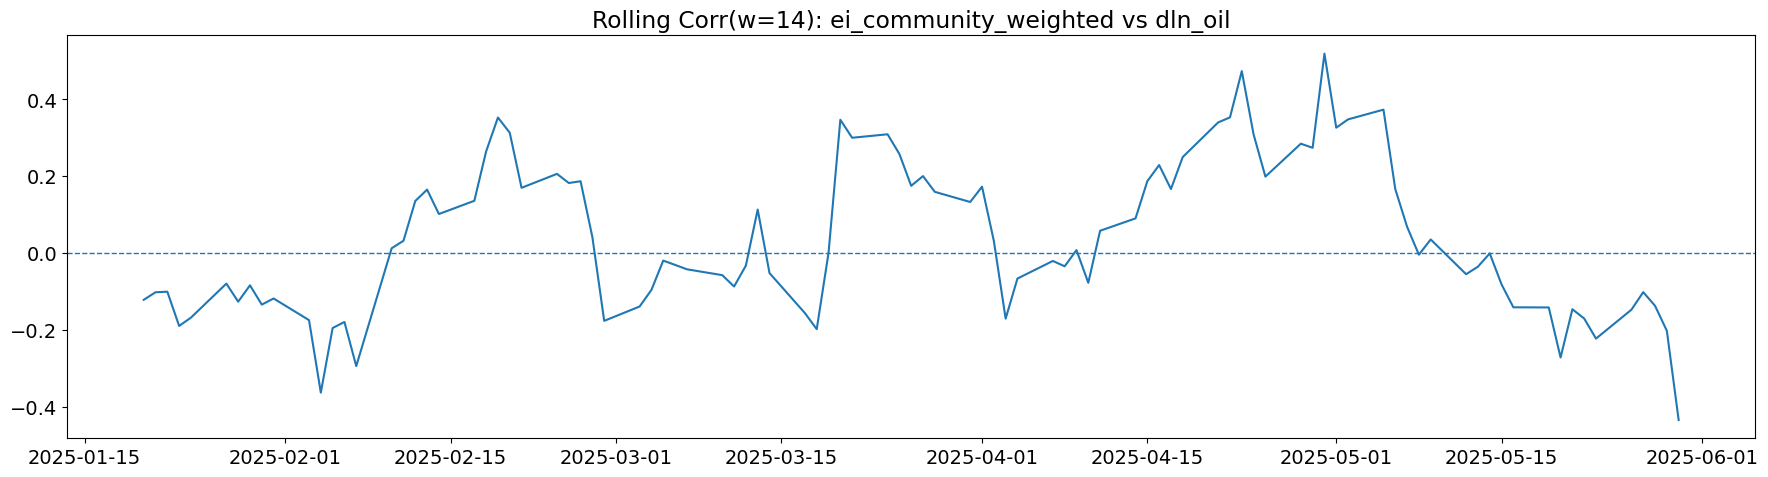

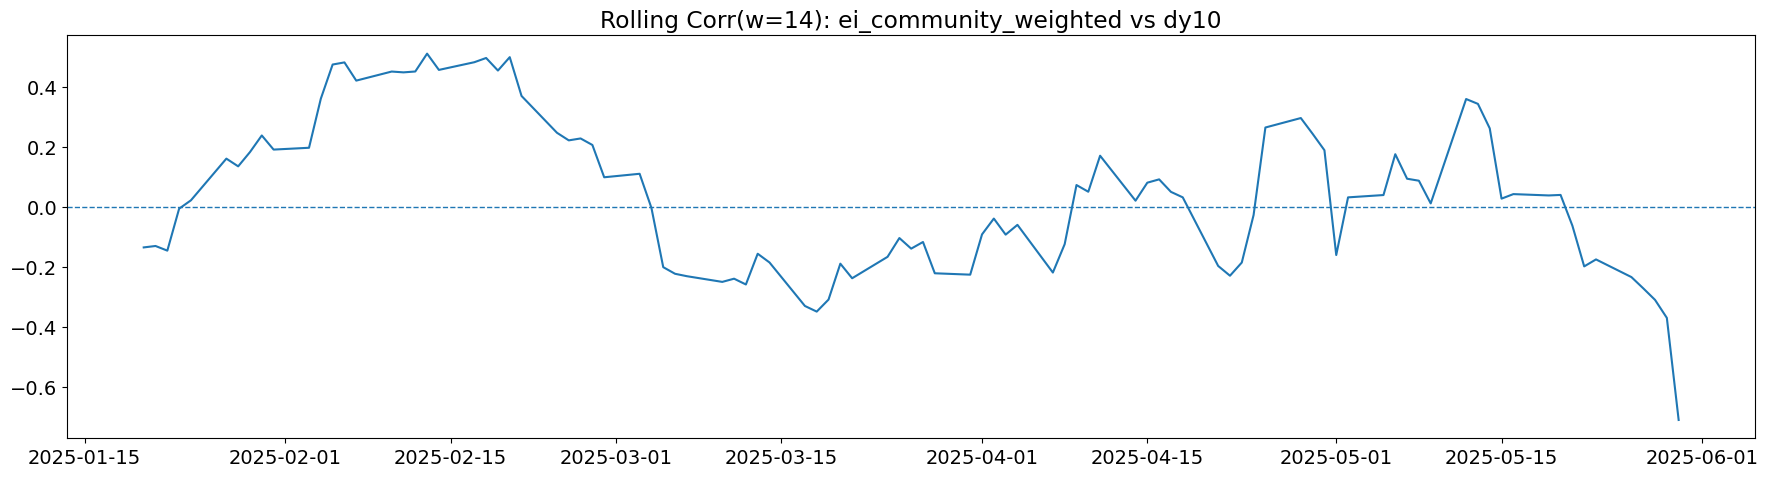

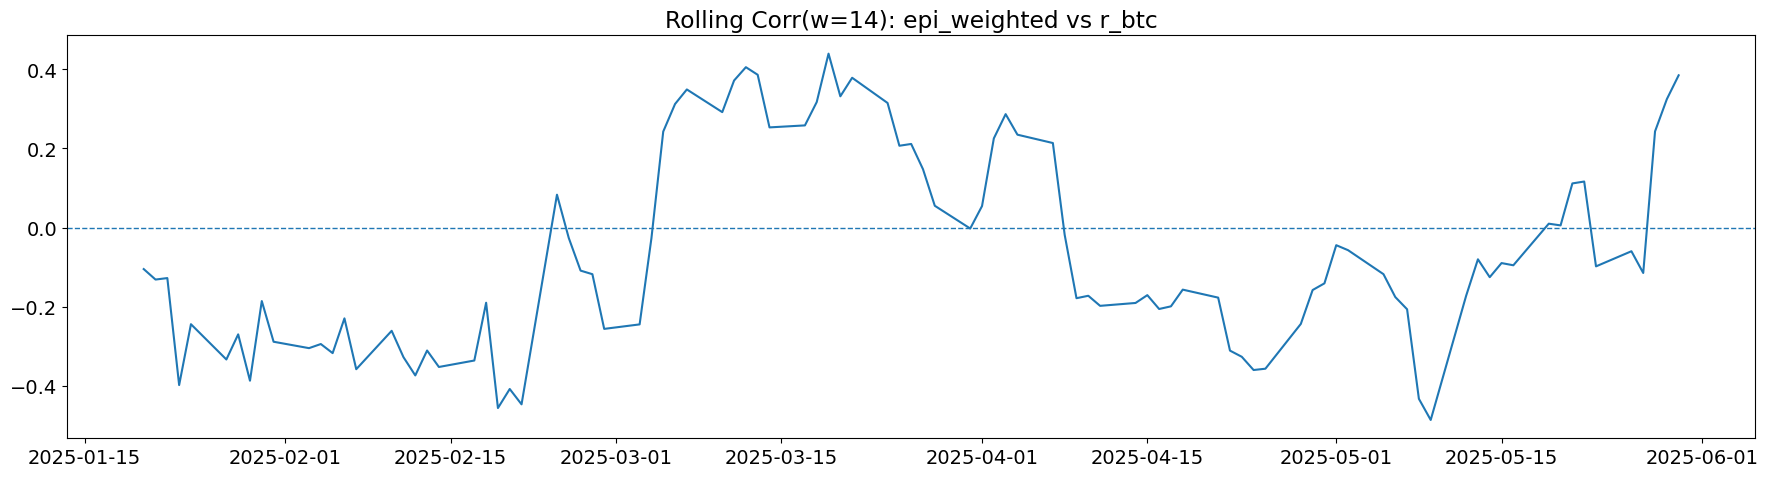

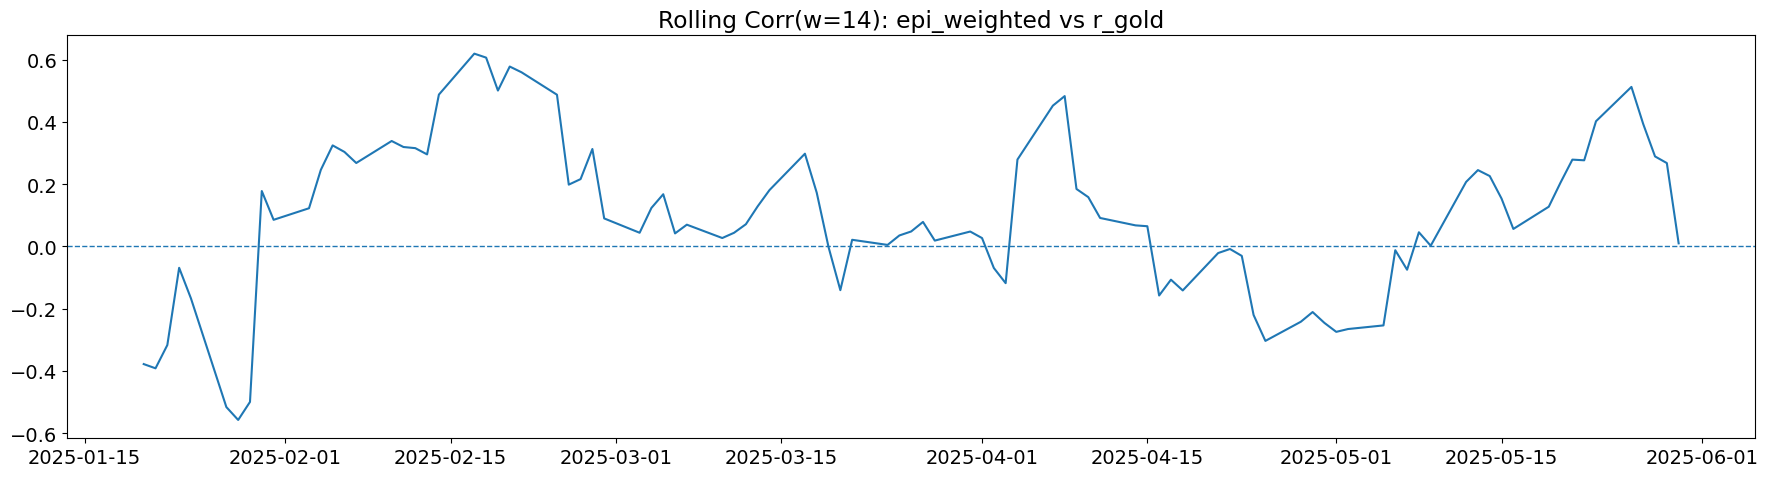

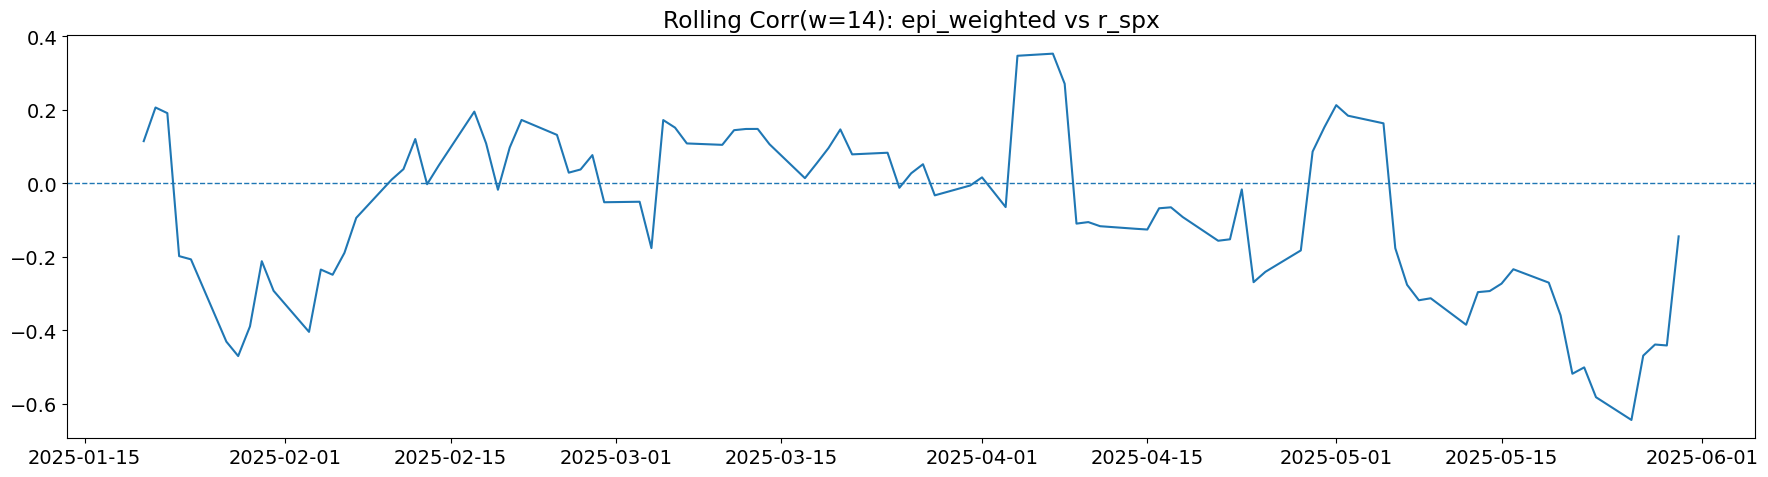

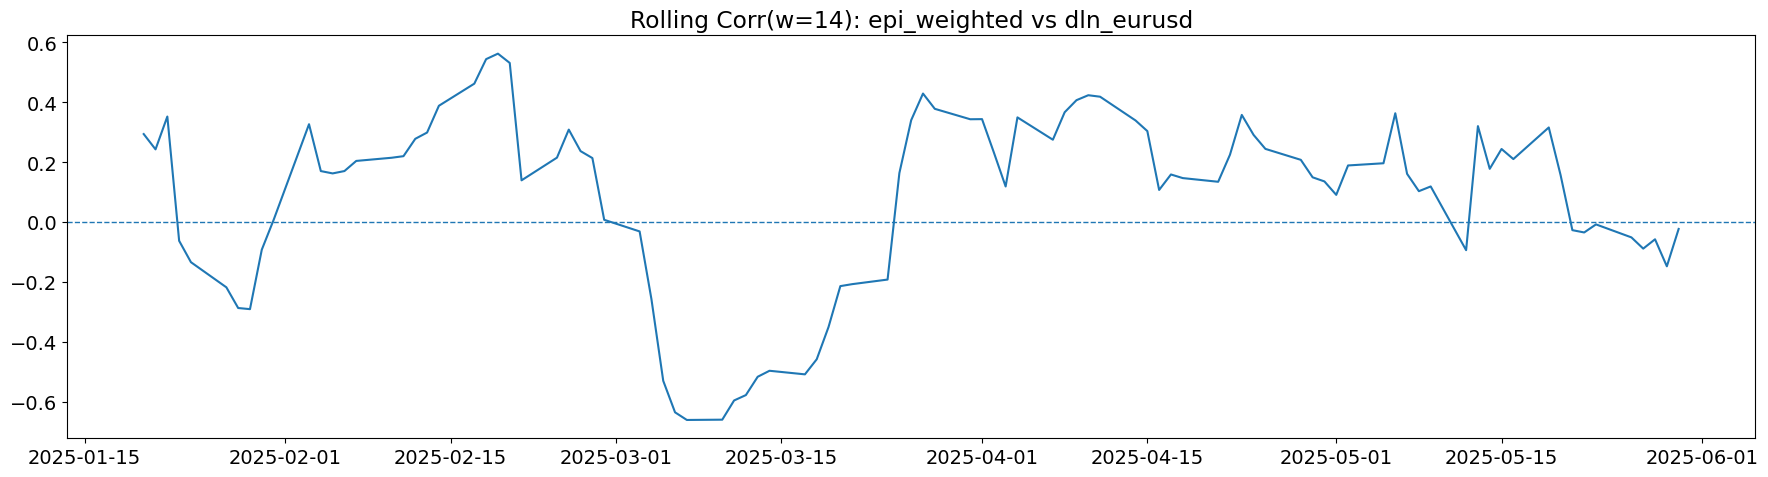

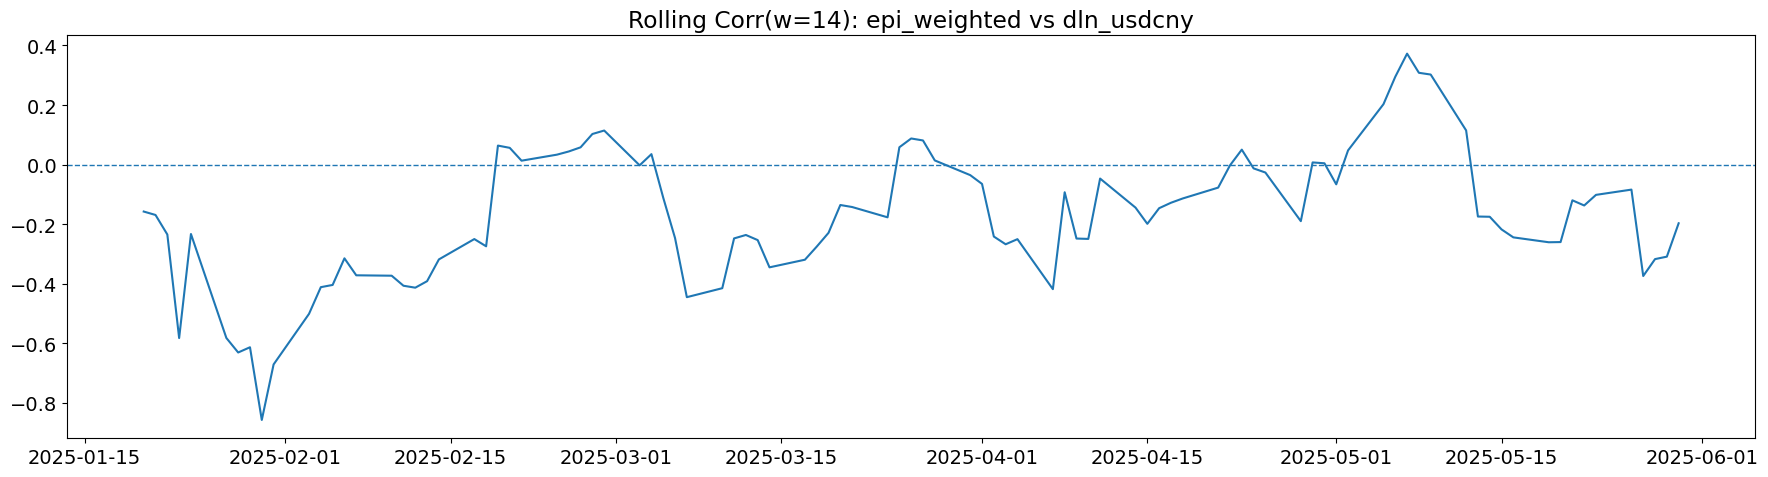

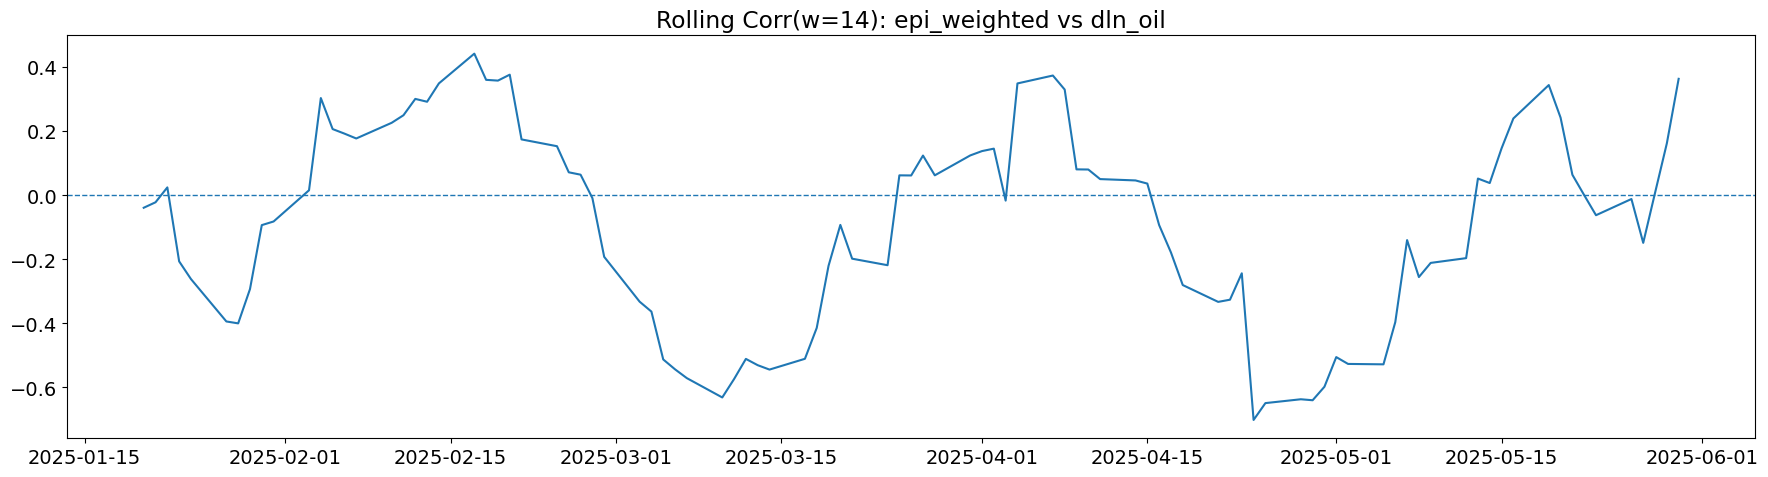

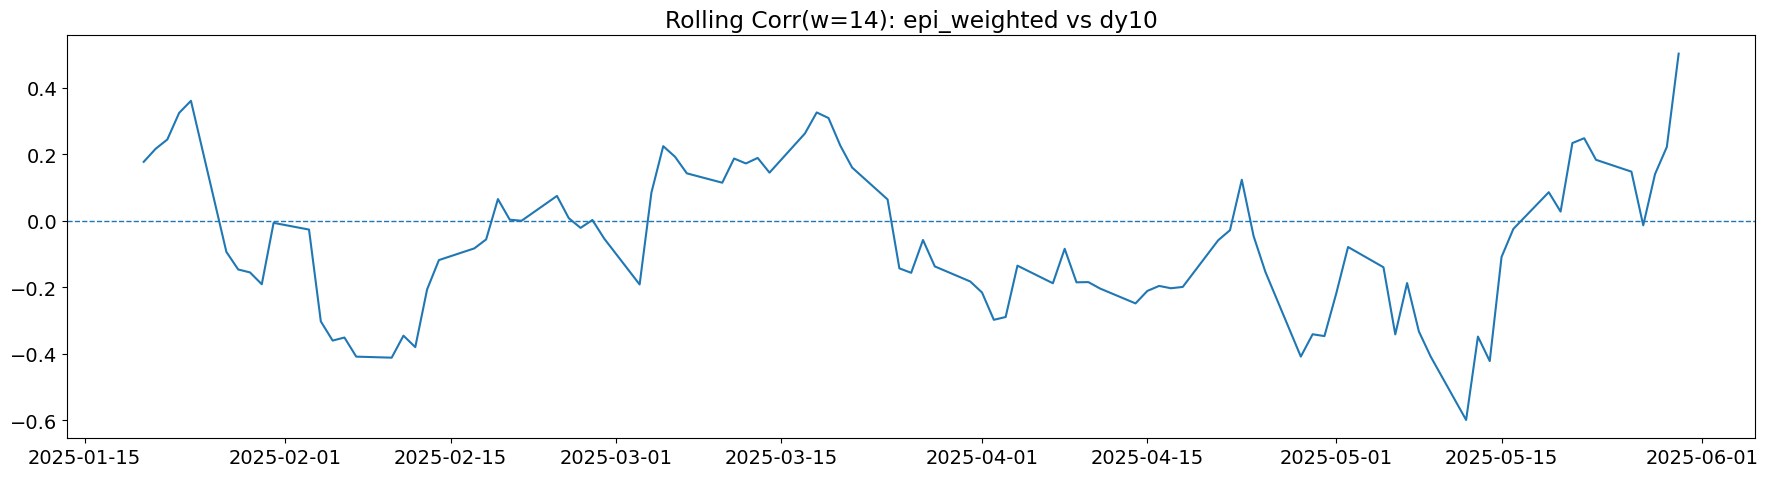

In [12]:
# rolling correlations (EI/EPI vs each market)
for base in plot_cols:
    for m in market_cols:
        rolling_corr_plot(df1, base, m, ROLLING_WINDOW)

### Lead–lag screening (aggregate)

lag,-10,-9,-8,-7,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5,6,7,8,9,10
corr,-0.05239,0.119016,-0.095585,-0.133593,0.020008,0.007545,0.109582,-0.041377,0.067918,0.012616,-0.413634,0.011415,-0.045431,-0.110147,0.056828,-0.153767,-0.010349,0.065232,-0.207335,-0.019974,0.144039


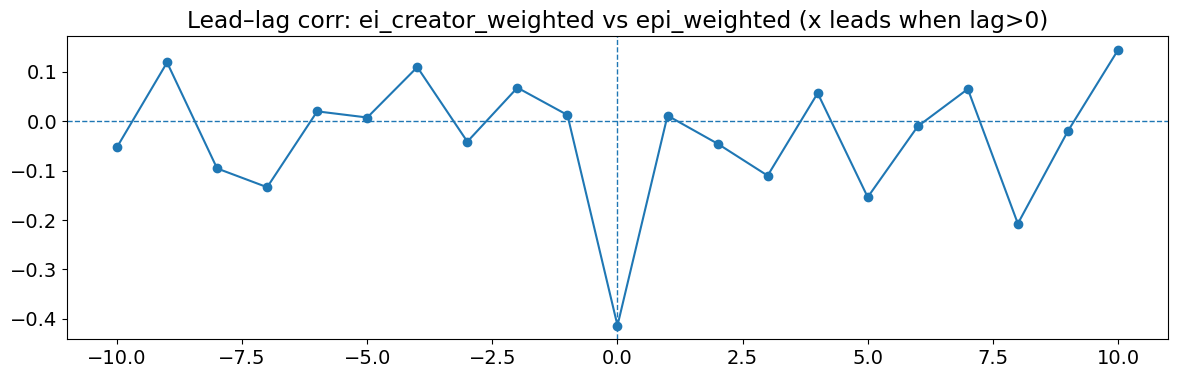

lag,-10,-9,-8,-7,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5,6,7,8,9,10
corr,0.109347,0.011973,-0.045937,-0.025534,-0.105474,-0.062123,-0.202359,-0.207725,-0.222051,-0.150962,-0.314085,-0.170962,-0.137341,-0.300161,-0.329521,-0.111006,-0.11728,0.042117,-0.013097,-0.042047,-0.019073


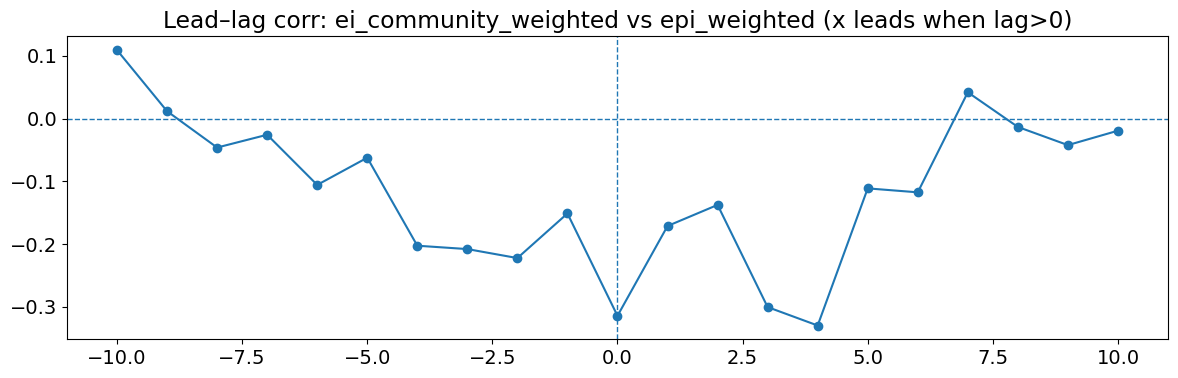

lag,-10,-9,-8,-7,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5,6,7,8,9,10
corr,0.05168,-0.092485,-0.060132,0.043779,0.027696,-0.067587,0.275095,0.231458,-0.055326,0.009161,-0.035845,0.093057,-0.084273,-0.15218,-0.071321,0.10916,-0.166179,-0.064715,0.133764,0.014774,-0.044984


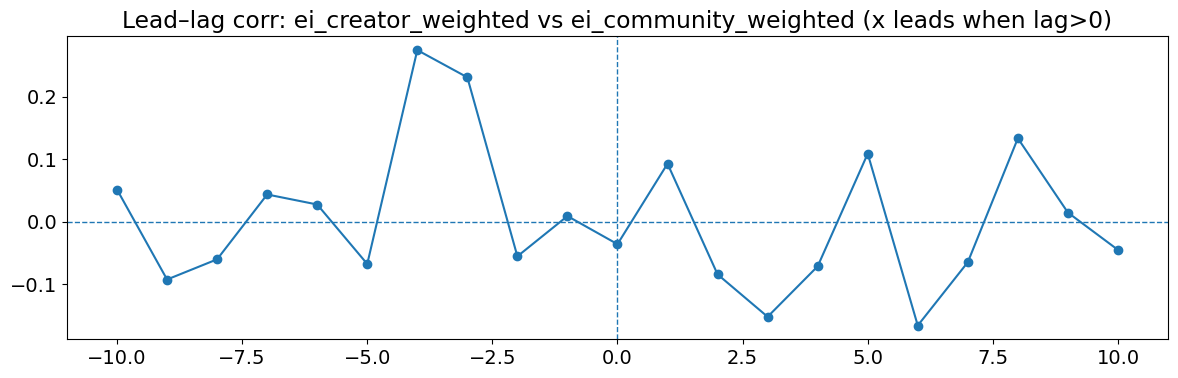

In [13]:
pairs = []
if "ei_creator_weighted" in df1.columns and "epi_weighted" in df1.columns:
    pairs.append(("ei_creator_weighted", "epi_weighted"))
if "ei_community_weighted" in df1.columns and "epi_weighted" in df1.columns:
    pairs.append(("ei_community_weighted", "epi_weighted"))
if "ei_creator_weighted" in df1.columns and "ei_community_weighted" in df1.columns:
    pairs.append(("ei_creator_weighted", "ei_community_weighted"))

for x, y in pairs:
    ll = lead_lag_corr(df1, x, y, MAX_LAG)
    display(ll.T)
    savecsv(ll, os.path.join(OUTDIR, f"leadlag_{x}_to_{y}.csv"))
    lead_lag_plot(ll, f"Lead–lag corr: {x} vs {y}")

### Topic dominance + entropy

,mean_abs,share
ei_creator_Security and Conflict,0.352833,0.108352
ei_creator_Social and Cultural Aspects,0.320343,0.098374
ei_creator_Legal and Regulatory Framework,0.319728,0.098185
ei_creator_Labor and Workforce,0.277154,0.085111
ei_creator_Economic and Financial Matters,0.264850,0.081333
ei_creator_Leadership and Governance,0.252342,0.077492
ei_creator_Health and Social Welfare,0.237191,0.072839
ei_creator_Disputes and Opinions,0.224655,0.068989
ei_creator_Miscellaneous and Other,0.206217,0.063327
ei_creator_Environmental and Infrastructure,0.196120,0.060227


,entropy,entropy_norm,concentration_1_minus_entropy_norm
count,1.080000e+02,1.080000e+02,108.000000
mean,1.265506e+00,4.378350e-01,0.562165
std,7.714285e-01,2.668959e-01,0.266896
min,-1.000089e-12,-3.460070e-13,0.192337
25%,6.852512e-01,2.370806e-01,0.331610
50%,1.500895e+00,5.192741e-01,0.480726
75%,1.931897e+00,6.683905e-01,0.762919
max,2.334446e+00,8.076631e-01,1.000000


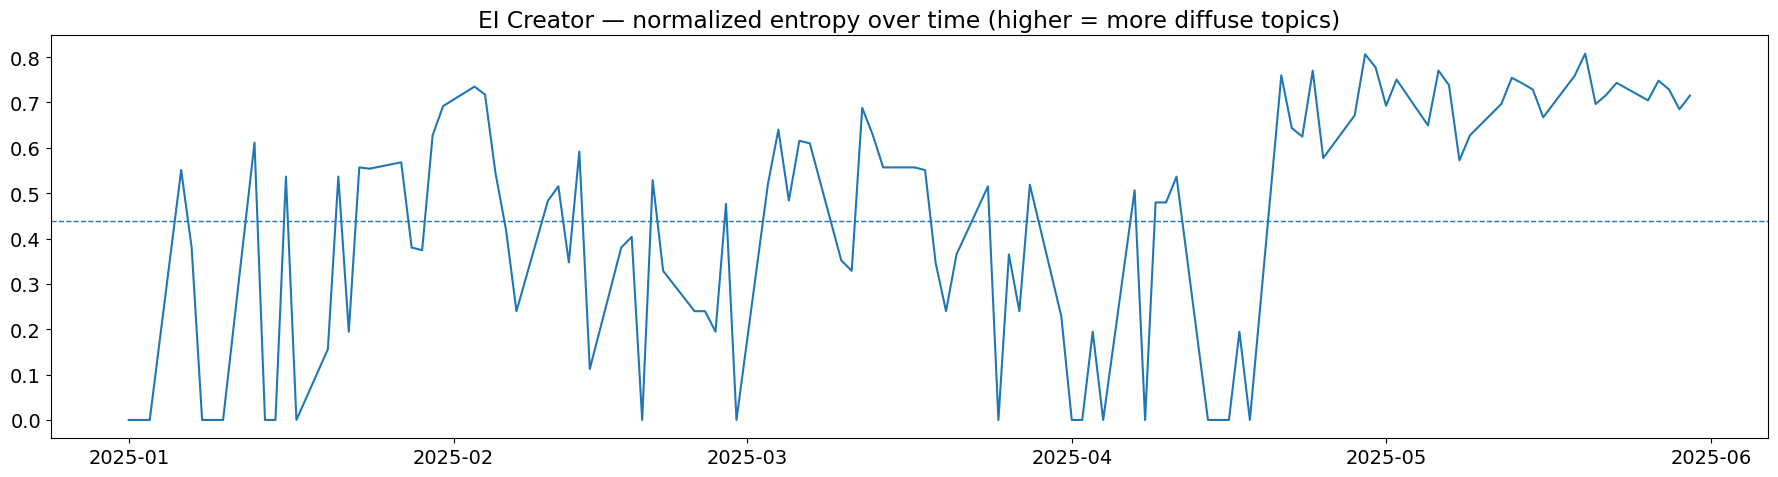

In [14]:
if ei_creator_topics:
    shares_c, ent_c = topic_share_entropy(df1, ei_creator_topics)
    display(shares_c.head(15))
    display(ent_c.describe())
    savecsv(shares_c, os.path.join(OUTDIR, "topic_shares_ei_creator.csv"))
    savecsv(ent_c, os.path.join(OUTDIR, "entropy_ei_creator.csv"))

    plt.figure(figsize=(18, 5))
    plt.plot(ent_c.index, ent_c["entropy_norm"])
    plt.title("EI Creator — normalized entropy over time (higher = more diffuse topics)")
    plt.axhline(ent_c["entropy_norm"].mean(), linestyle="--", linewidth=1)
    plt.tight_layout()
    plt.show()
    savefig(os.path.join(OUTDIR, "entropy_norm_ei_creator.png"))

,mean_abs,share
ei_community_Quality of Life and Standards,0.490268,0.077836
ei_community_Conspiracy and Historical Events,0.455666,0.072342
"ei_community_Trust, Credibility, and Communication",0.438276,0.069582
ei_community_Legal and Regulatory Framework,0.435446,0.069132
ei_community_Leadership and Governance,0.413306,0.065617
ei_community_Sports and Recreation,0.409316,0.064984
ei_community_Psychological and Emotional Aspects,0.399142,0.063369
ei_community_Disputes and Opinions,0.398706,0.063299
ei_community_Power and Influence Dynamics,0.376261,0.059736
ei_community_Disaster and Resilience,0.368682,0.058533


,entropy,entropy_norm,concentration_1_minus_entropy_norm
count,108.000000,108.000000,108.000000
mean,2.462098,0.851827,0.148173
std,0.512694,0.177380,0.177380
min,-0.000000,-0.000000,0.023689
25%,2.455261,0.849462,0.075087
50%,2.576640,0.891456,0.108544
75%,2.673343,0.924913,0.150538
max,2.821901,0.976311,1.000000


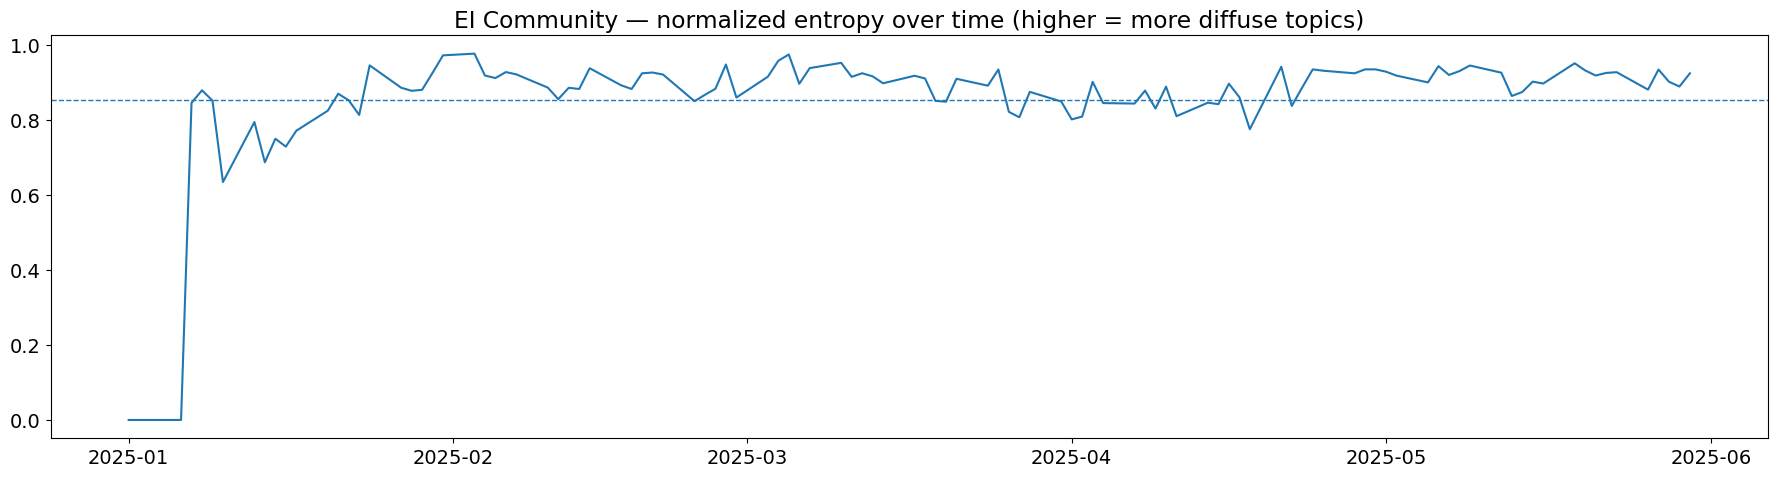

In [15]:
if ei_community_topics:
    shares_m, ent_m = topic_share_entropy(df1, ei_community_topics)
    display(shares_m.head(15))
    display(ent_m.describe())
    savecsv(shares_m, os.path.join(OUTDIR, "topic_shares_ei_community.csv"))
    savecsv(ent_m, os.path.join(OUTDIR, "entropy_ei_community.csv"))

    plt.figure(figsize=(18, 5))
    plt.plot(ent_m.index, ent_m["entropy_norm"])
    plt.title("EI Community — normalized entropy over time (higher = more diffuse topics)")
    plt.axhline(ent_m["entropy_norm"].mean(), linestyle="--", linewidth=1)
    plt.tight_layout()
    plt.show()
    savefig(os.path.join(OUTDIR, "entropy_norm_ei_community.png"))

,mean_abs,share
epi_Quality of Life and Standards,0.623805,0.072017
epi_Legal and Regulatory Framework,0.604213,0.069755
epi_Disputes and Opinions,0.562410,0.064929
epi_Leadership and Governance,0.552840,0.063825
epi_Security and Conflict,0.524113,0.060508
epi_Sports and Recreation,0.523928,0.060487
epi_Psychological and Emotional Aspects,0.512267,0.059140
epi_Conspiracy and Historical Events,0.502168,0.057975
"epi_Trust, Credibility, and Communication",0.494403,0.057078
epi_Health and Social Welfare,0.470976,0.054374


,entropy,entropy_norm,concentration_1_minus_entropy_norm
count,1.080000e+02,1.080000e+02,108.000000
mean,2.499148e+00,8.646457e-01,0.135354
std,4.579900e-01,1.584537e-01,0.158454
min,-1.000089e-12,-3.460070e-13,0.032673
25%,2.506044e+00,8.670318e-01,0.077706
50%,2.605133e+00,9.013140e-01,0.098686
75%,2.665773e+00,9.222942e-01,0.132968
max,2.795934e+00,9.673268e-01,1.000000


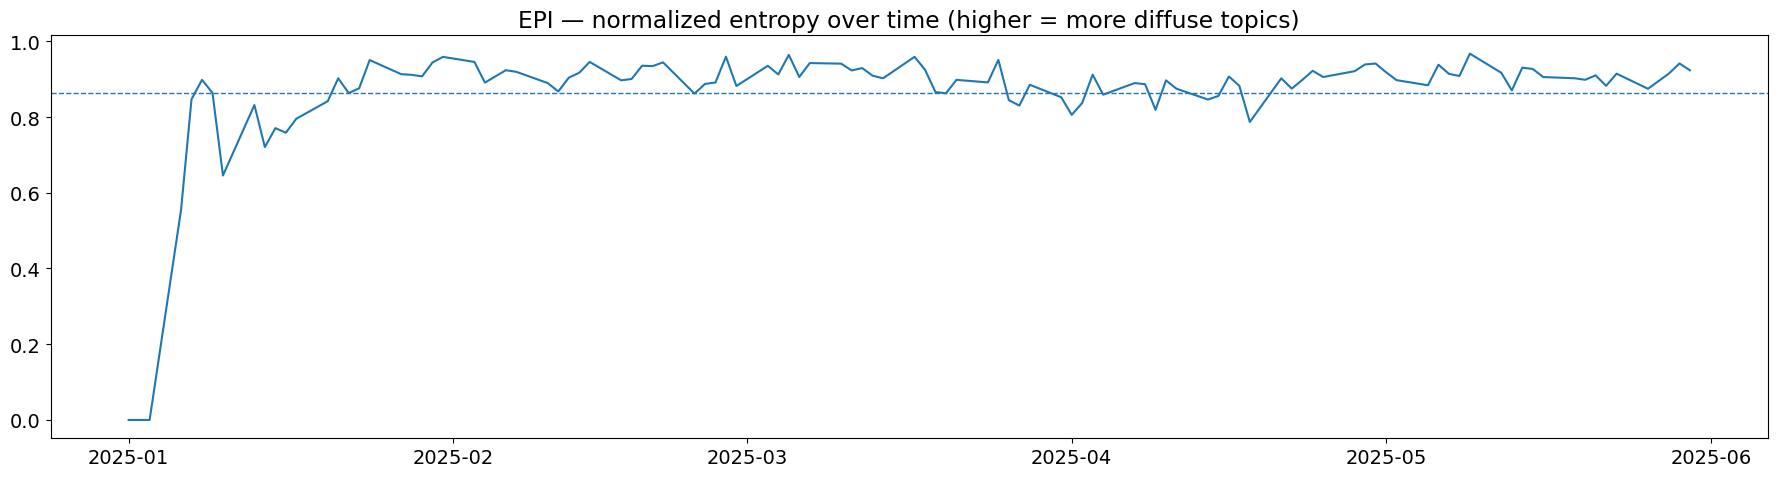

In [16]:
if epi_topics:
    shares_e, ent_e = topic_share_entropy(df1, epi_topics)
    display(shares_e.head(15))
    display(ent_e.describe())
    savecsv(shares_e, os.path.join(OUTDIR, "topic_shares_epi.csv"))
    savecsv(ent_e, os.path.join(OUTDIR, "entropy_epi.csv"))

    plt.figure(figsize=(18, 5))
    plt.plot(ent_e.index, ent_e["entropy_norm"])
    plt.title("EPI — normalized entropy over time (higher = more diffuse topics)")
    plt.axhline(ent_e["entropy_norm"].mean(), linestyle="--", linewidth=1)
    plt.tight_layout()
    plt.show()
    savefig(os.path.join(OUTDIR, "entropy_norm_epi.png"))

### Creator vs Community divergence (topic-wise + weighted)

count    108.000000
mean       0.150035
std        0.574018
min       -1.158790
25%       -0.171390
50%        0.151441
75%        0.516499
max        1.392279
dtype: float64

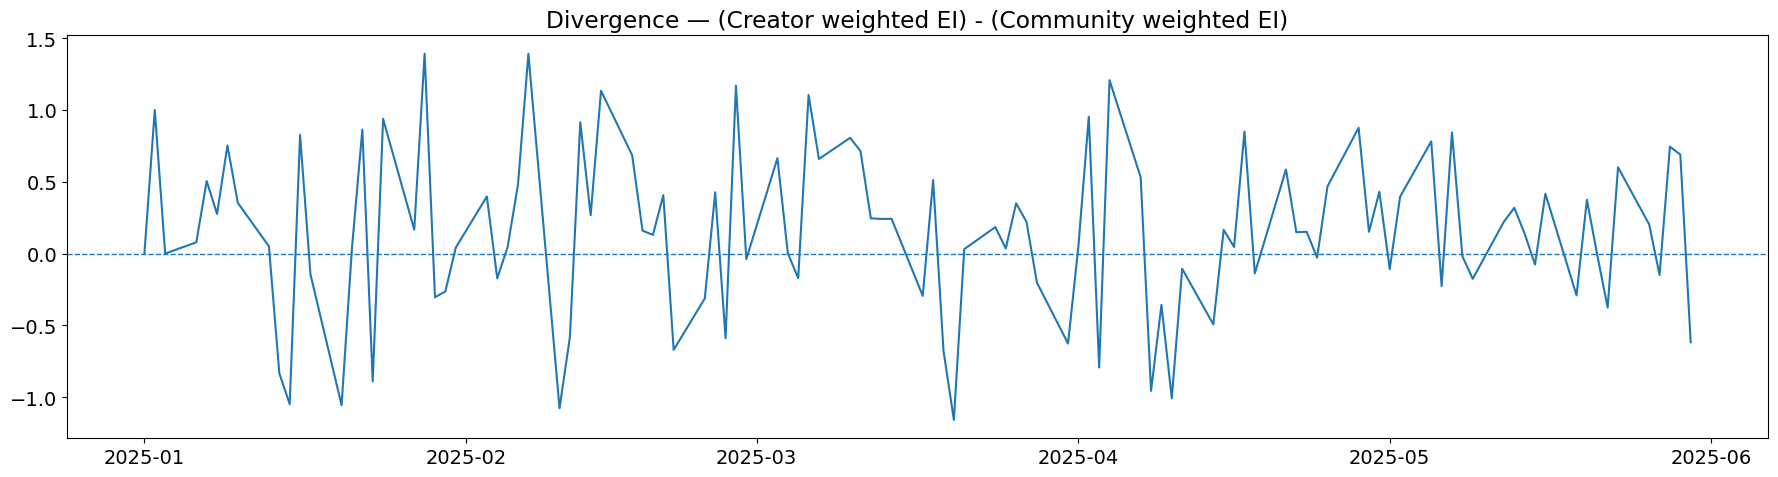

In [17]:
if "ei_creator_weighted" in df1.columns and "ei_community_weighted" in df1.columns:
    div_w = df1["ei_creator_weighted"] - df1["ei_community_weighted"]
    display(div_w.describe())

    plt.figure(figsize=(18, 5))
    plt.plot(df1.index, div_w)
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title("Divergence — (Creator weighted EI) - (Community weighted EI)")
    plt.tight_layout()
    plt.show()
    savefig(os.path.join(OUTDIR, "divergence_weighted.png"))

count    108.000000
mean       0.150035
std        0.574018
min       -1.158790
25%       -0.171390
50%        0.151441
75%        0.516499
max        1.392279
dtype: float64

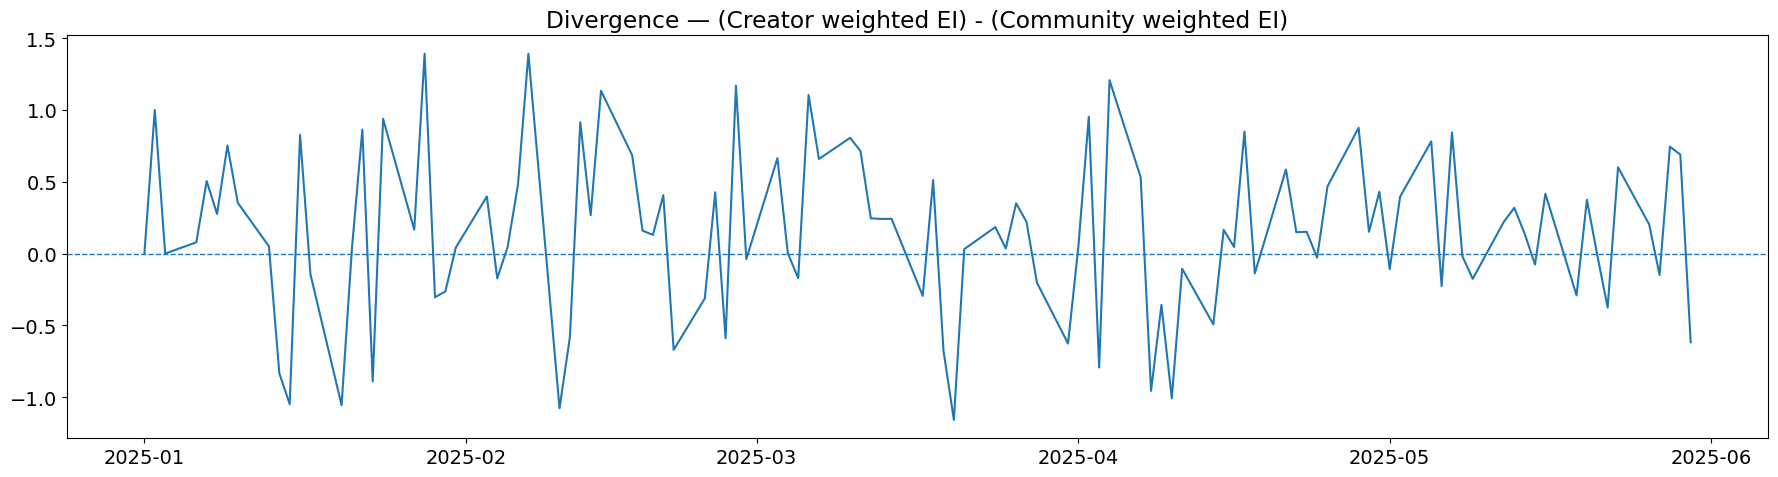

In [18]:
if "ei_creator_weighted" in df1.columns and "ei_community_weighted" in df1.columns:
    div_w = df1["ei_creator_weighted"] - df1["ei_community_weighted"]
    display(div_w.describe())

    plt.figure(figsize=(18, 5))
    plt.plot(df1.index, div_w)
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title("Divergence — (Creator weighted EI) - (Community weighted EI)")
    plt.tight_layout()
    plt.show()
    savefig(os.path.join(OUTDIR, "divergence_weighted.png"))

### Event-window pre/during/post tables

In [19]:
EVENT_WINDOWS = [
    ("Initial Tariff Announcements", "2025-01-20", "2025-01-26"),
    ("Tariffs Postponed", "2025-03-04", "2025-03-06"),
    ("China Retaliation & US Tariffs Imposed", "2025-03-10", "2025-03-13"),
    ("Global Tariffs & China Retaliation", "2025-04-02", "2025-04-06"),
    ("US-China Tariff Threats", "2025-04-09", "2025-04-12"),
    ("Tariffs Relaxed", "2025-04-27", "2025-05-04"),
    ("Trade Deals & US-China Tariff Rollbacks", "2025-05-05", "2025-05-14"),
    ("Non-US Manufactured Apple Tariff Threat", "2025-05-20", "2025-05-25"),
]

EVENT_COLS = plot_cols  # weighted EI/EPI
PRE_DAYS, POST_DAYS = 7, 7

rows = []
for name, start_s, end_s in EVENT_WINDOWS:
    start, end = pd.to_datetime(start_s), pd.to_datetime(end_s)

    pre = df1.loc[(df1.index >= start - pd.Timedelta(days=PRE_DAYS)) & (df1.index < start), EVENT_COLS]
    dur = df1.loc[(df1.index >= start) & (df1.index <= end), EVENT_COLS]
    post = df1.loc[(df1.index > end) & (df1.index <= end + pd.Timedelta(days=POST_DAYS)), EVENT_COLS]

    for phase, block in [("pre", pre), ("during", dur), ("post", post)]:
        row = {"event": name, "phase": phase, "n": len(block)}
        for c in EVENT_COLS:
            row[f"{c}_mean"] = block[c].mean()
            row[f"{c}_std"] = block[c].std()
        rows.append(row)

    # deltas
    pre_m, dur_m, post_m = pre.mean(), dur.mean(), post.mean()

    row = {"event": name, "phase": "delta_during_minus_pre", "n": np.nan}
    for c in EVENT_COLS:
        row[f"{c}_mean"] = dur_m[c] - pre_m[c]
        row[f"{c}_std"] = np.nan
    rows.append(row)

    row = {"event": name, "phase": "delta_post_minus_during", "n": np.nan}
    for c in EVENT_COLS:
        row[f"{c}_mean"] = post_m[c] - dur_m[c]
        row[f"{c}_std"] = np.nan
    rows.append(row)

event_tbl = pd.DataFrame(rows)
display(event_tbl)
savecsv(event_tbl, os.path.join(OUTDIR, "event_windows_pre_during_post.csv"))


,event,phase,n,ei_creator_weighted_mean,ei_creator_weighted_std,ei_community_weighted_mean,ei_community_weighted_std,epi_weighted_mean,epi_weighted_std
0,Initial Tariff Announcements,pre,5.0,-0.181119,0.832328,0.048800,0.267496,-0.802759,0.093258
1,Initial Tariff Announcements,during,5.0,-0.008591,0.553308,0.012723,0.492949,-0.712781,0.144800
2,Initial Tariff Announcements,post,5.0,-0.147039,0.700421,-0.353491,0.229135,-0.471022,0.448264
3,Initial Tariff Announcements,delta_during_minus_pre,NaN,0.172527,NaN,-0.036077,NaN,0.089978,NaN
4,Initial Tariff Announcements,delta_post_minus_during,NaN,-0.138447,NaN,-0.366214,NaN,0.241758,NaN
5,Tariffs Postponed,pre,5.0,0.046583,0.555480,-0.279901,0.247242,-0.549738,0.186262
6,Tariffs Postponed,during,3.0,-0.015751,0.693055,-0.327692,0.007716,-0.211434,0.182288
7,Tariffs Postponed,post,5.0,0.247899,0.316261,-0.285179,0.087807,-0.502952,0.153471
8,Tariffs Postponed,delta_during_minus_pre,NaN,-0.062334,NaN,-0.047790,NaN,0.338304,NaN
9,Tariffs Postponed,delta_post_minus_during,NaN,0.263650,NaN,0.042512,NaN,-0.291518,NaN


### PCA (topic EI only; creator/community separately)

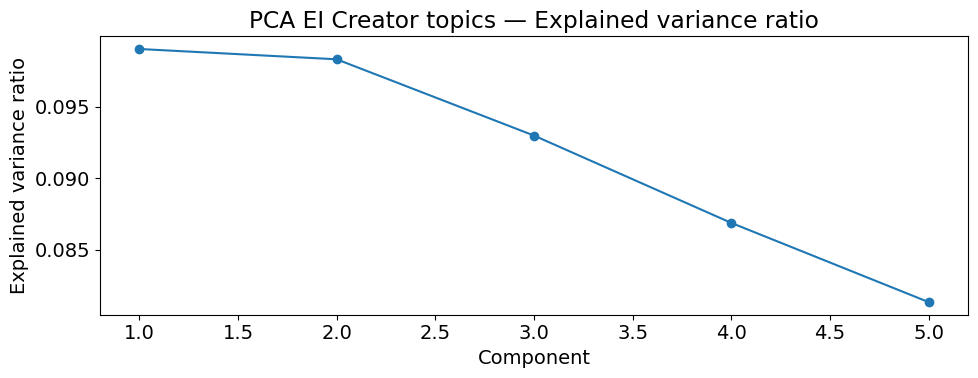

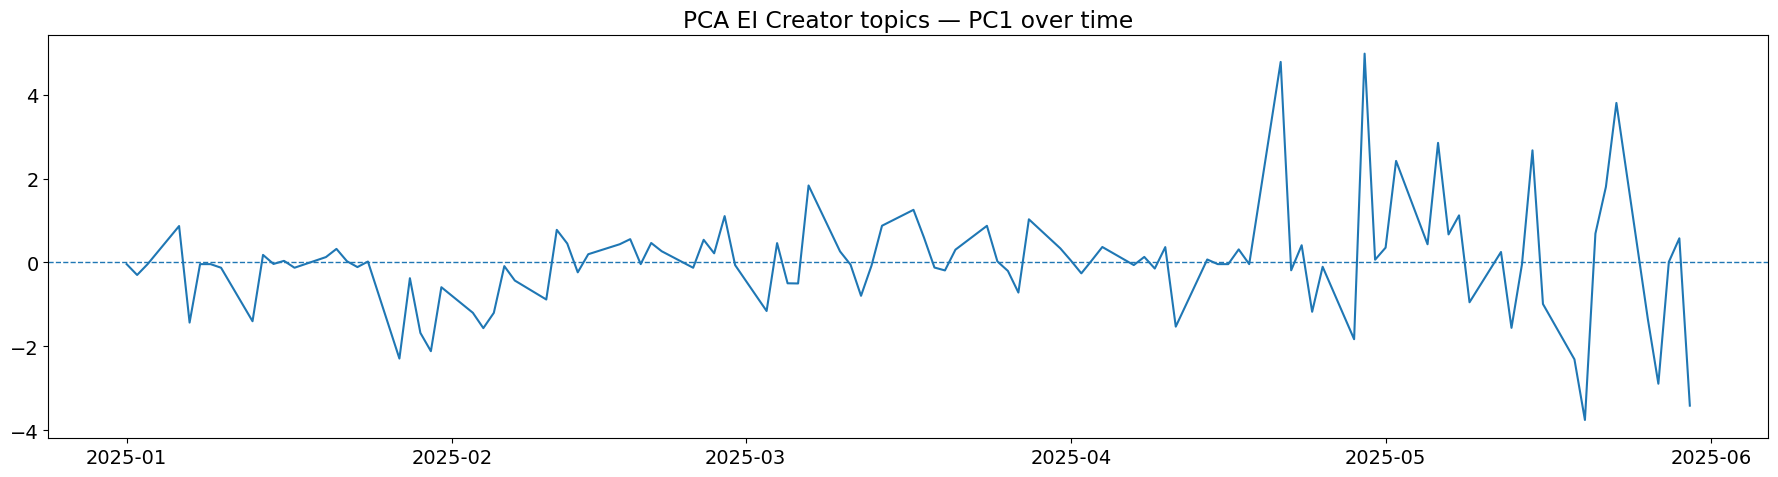

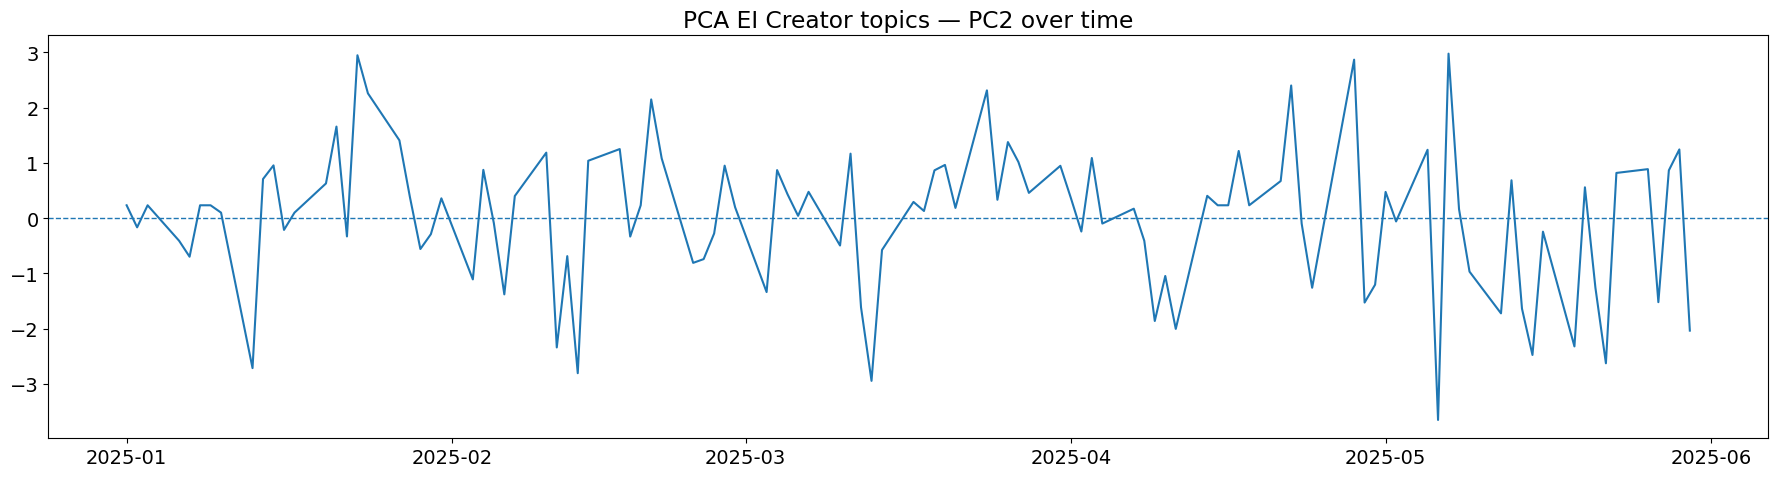

,PC1,PC2,PC3,PC4,PC5
ei_creator_Education and Knowledge,0.480534,0.095025,0.317438,0.229639,0.100029
ei_creator_Health and Social Welfare,0.418628,0.025987,0.195911,0.305675,0.126091
ei_creator_Quality of Life and Standards,0.327830,0.134846,0.271249,0.053741,0.354705
ei_creator_Disaster and Resilience,0.285738,0.088385,0.005780,0.193730,0.500572
"ei_creator_Trust, Credibility, and Communication",0.271399,0.099042,0.412927,0.302068,0.002098
ei_creator_Power and Influence Dynamics,0.253862,0.275877,0.165283,0.445760,0.147827
ei_creator_Psychological and Emotional Aspects,0.234642,0.238147,0.230690,0.083383,0.366661
ei_creator_Miscellaneous and Other,0.219655,0.186437,0.050904,0.401955,0.009953
ei_creator_Environmental and Infrastructure,0.211816,0.194346,0.057238,0.170191,0.112548
ei_creator_Legal and Regulatory Framework,0.202480,0.012746,0.225567,0.195284,0.195249


In [20]:
if ei_creator_topics and len(ei_creator_topics) >= 5:
    pca_c, load_c, pcs_c = run_pca(df1, ei_creator_topics, PCA_COMPONENTS, "PCA EI Creator topics")
    if load_c is not None:
        display(load_c.abs().sort_values("PC1", ascending=False).head(15))

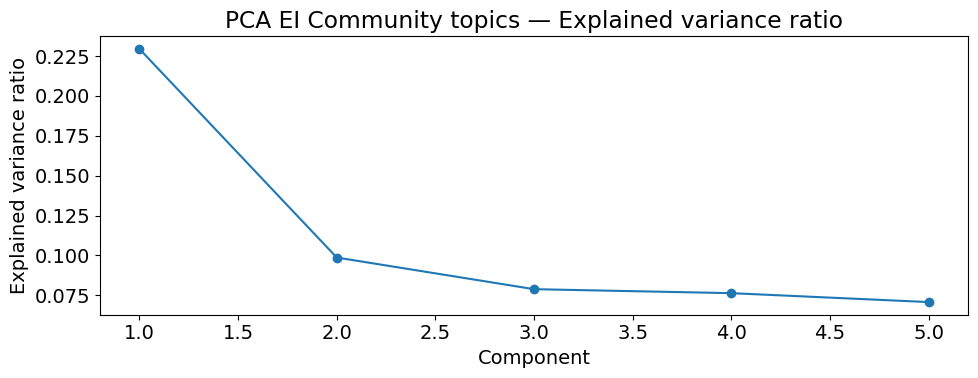

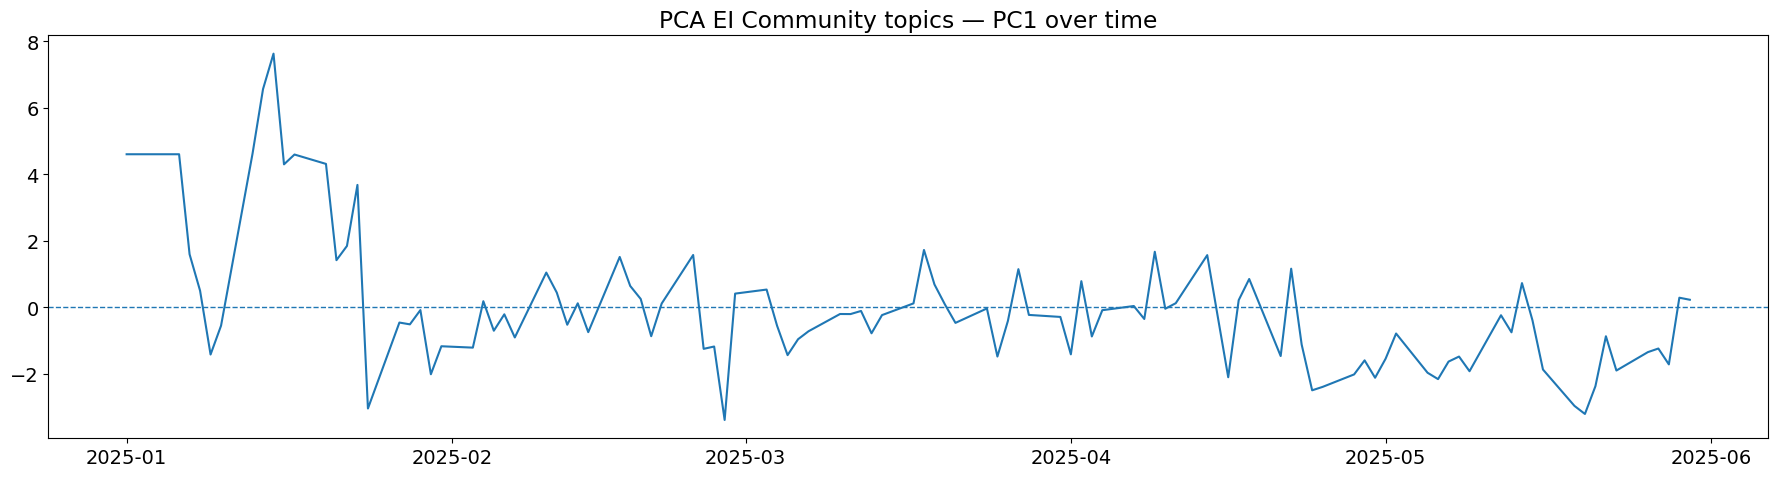

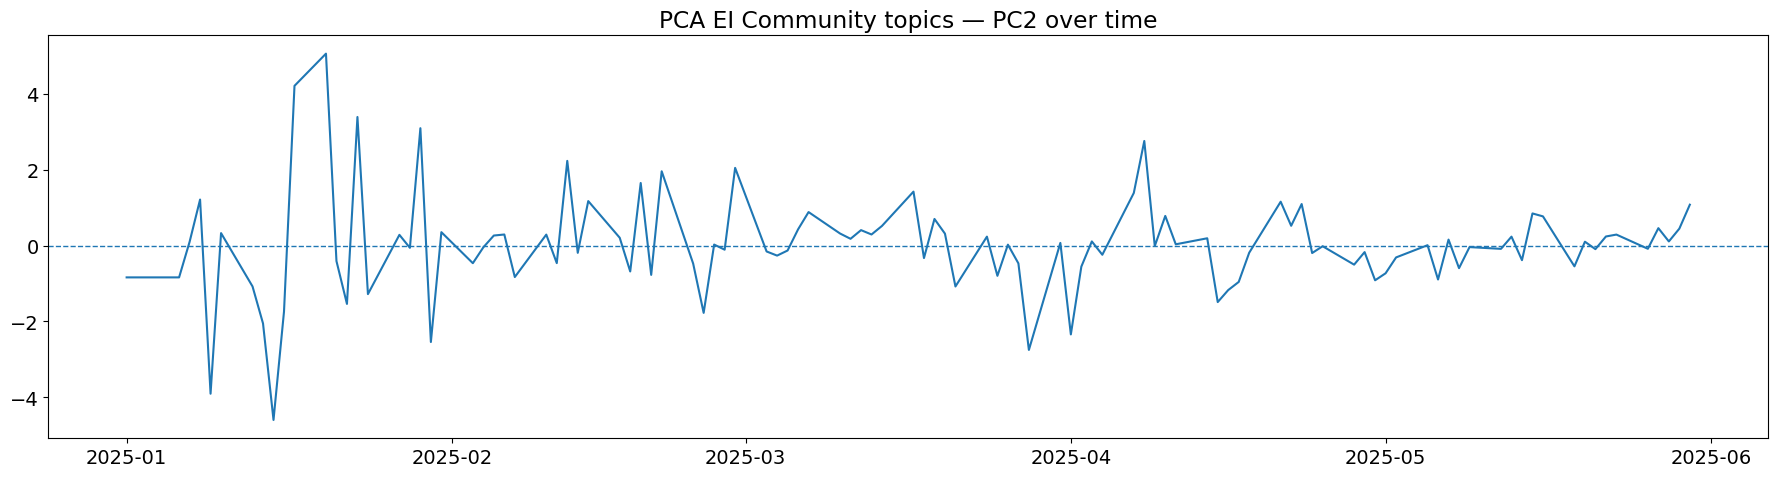

,PC1,PC2,PC3,PC4,PC5
ei_community_Social and Cultural Aspects,0.417510,0.044287,0.094219,0.046035,0.061564
ei_community_Leadership and Governance,0.417477,0.011636,0.141745,0.029237,0.107766
ei_community_Legal and Regulatory Framework,0.408627,0.084168,0.021650,0.078551,0.129150
ei_community_Security and Conflict,0.335589,0.245161,0.059752,0.042790,0.221011
ei_community_Economic and Financial Matters,0.327668,0.311488,0.070790,0.095100,0.173859
ei_community_Disputes and Opinions,0.235637,0.260332,0.125139,0.379680,0.073244
ei_community_Labor and Workforce,0.231869,0.325977,0.130292,0.366633,0.121674
ei_community_Miscellaneous and Other,0.175417,0.197809,0.135922,0.218462,0.222800
ei_community_Disaster and Resilience,0.167852,0.179594,0.115023,0.253113,0.171266
ei_community_Power and Influence Dynamics,0.167356,0.106808,0.300635,0.091976,0.145037


In [21]:
if ei_community_topics and len(ei_community_topics) >= 5:
    pca_m, load_m, pcs_m = run_pca(df1, ei_community_topics, PCA_COMPONENTS, "PCA EI Community topics")
    if load_m is not None:
        display(load_m.abs().sort_values("PC1", ascending=False).head(15))

### Risk Sentiment
Do emotional narratives co-move with asset returns in ways consistent with risk-on / risk-off behaviour?

,r_btc,r_gold,r_spx
epi_weighted,-0.030870,0.017917,-0.028793
ei_creator_weighted,-0.042575,-0.087998,-0.110339
ei_community_weighted,0.082395,0.009494,0.105972


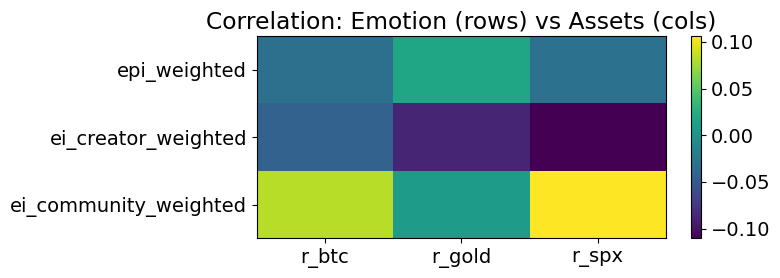

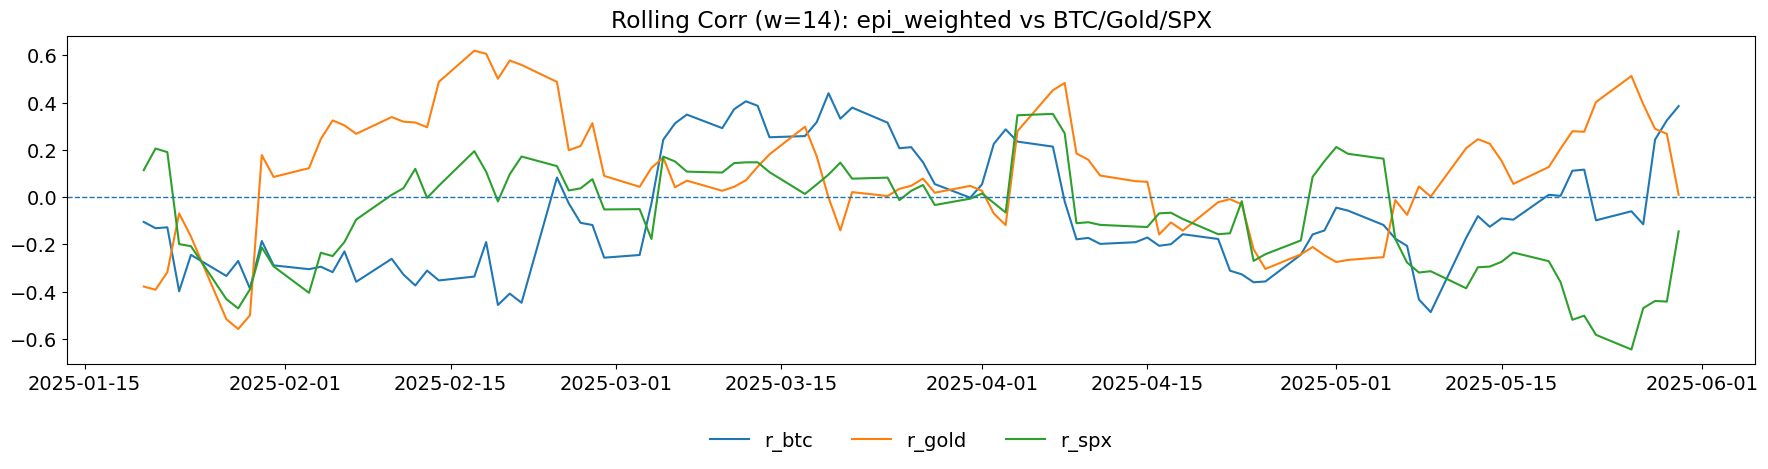

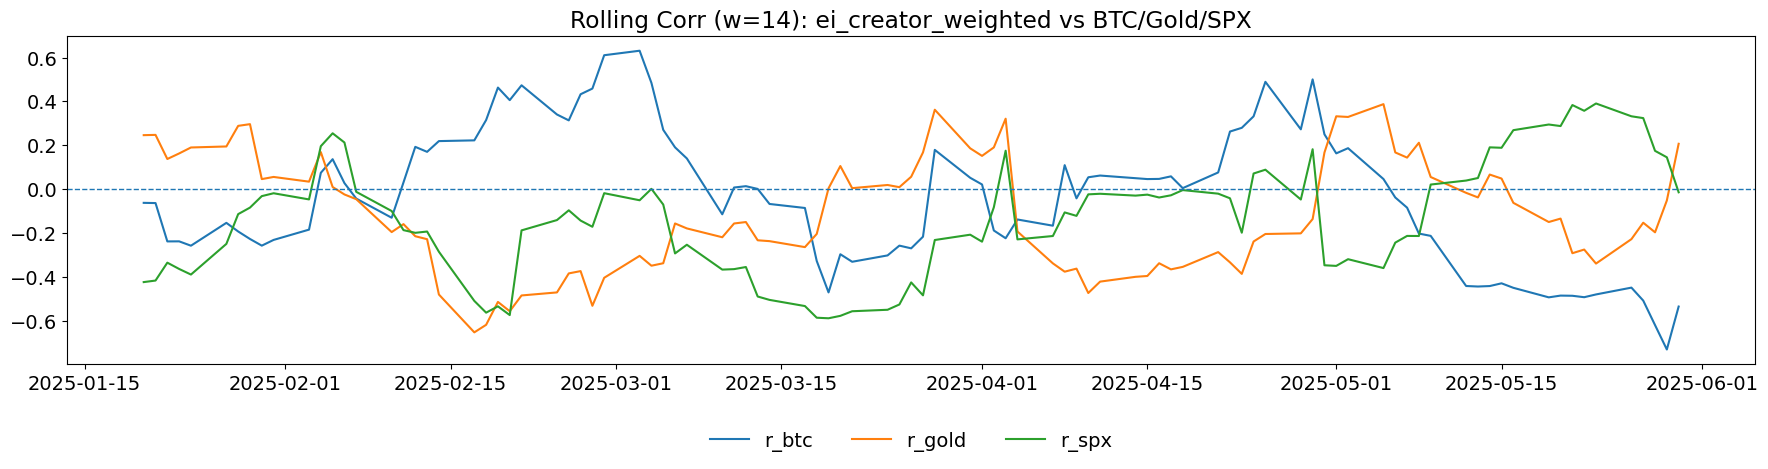

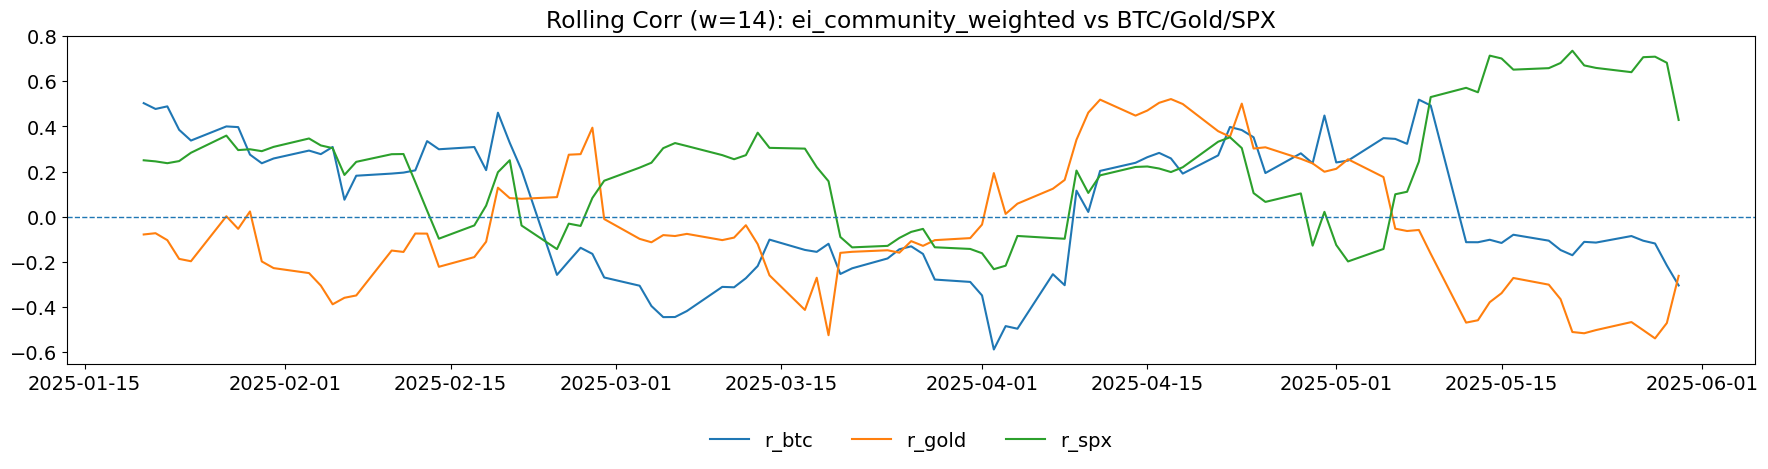

In [22]:
ASSETS = ["r_btc", "r_gold", "r_spx"]
EMO = ["epi_weighted", "ei_creator_weighted", "ei_community_weighted"]
ASSETS = [c for c in ASSETS if c in df1.columns]
EMO = [c for c in EMO if c in df1.columns]

corr = df1[ASSETS + EMO].corr().loc[EMO, ASSETS]
display(corr)

plt.figure(figsize=(8, 3))
plt.imshow(corr.values, aspect="auto")
plt.xticks(range(len(ASSETS)), ASSETS, rotation=0)
plt.yticks(range(len(EMO)), EMO)
plt.title("Correlation: Emotion (rows) vs Assets (cols)")
plt.colorbar()
plt.tight_layout()
plt.show()

W = 14
for e in EMO:
    plt.figure(figsize=(18, 5))
    for a in ASSETS:
        plt.plot(df1.index, df1[e].rolling(W).corr(df1[a]), label=a)
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title(f"Rolling Corr (w={W}): {e} vs BTC/Gold/SPX")
    plt.legend(ncol=3, frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.15))
    plt.tight_layout()
    plt.show()

### Lead–lag with BTC/Gold/SPX

lag,-10,-9,-8,-7,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5,6,7,8,9,10
corr,-0.009338,0.105363,0.0325,0.017335,0.046284,-0.004381,0.032849,0.066028,-0.005985,0.061486,-0.03087,0.027192,-0.166606,-0.096071,-0.106296,-0.049277,0.017299,0.009399,0.000557,0.071816,0.102393


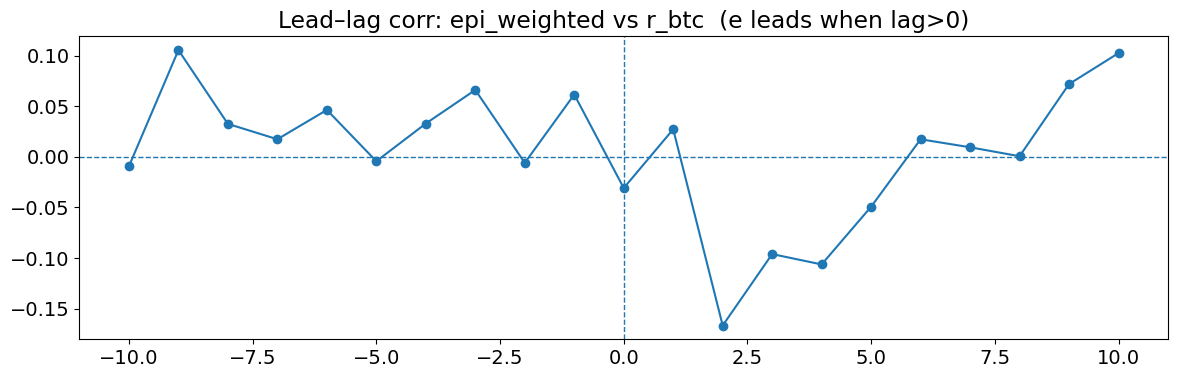

lag,-10,-9,-8,-7,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5,6,7,8,9,10
corr,-0.017847,-0.070141,0.020084,-0.073486,-0.029233,-0.021647,-0.20967,-0.082553,-0.014324,0.063515,0.017917,0.002185,-0.024747,-0.097179,-0.030023,0.029285,0.077458,-0.044005,-0.091977,-0.047748,0.035944


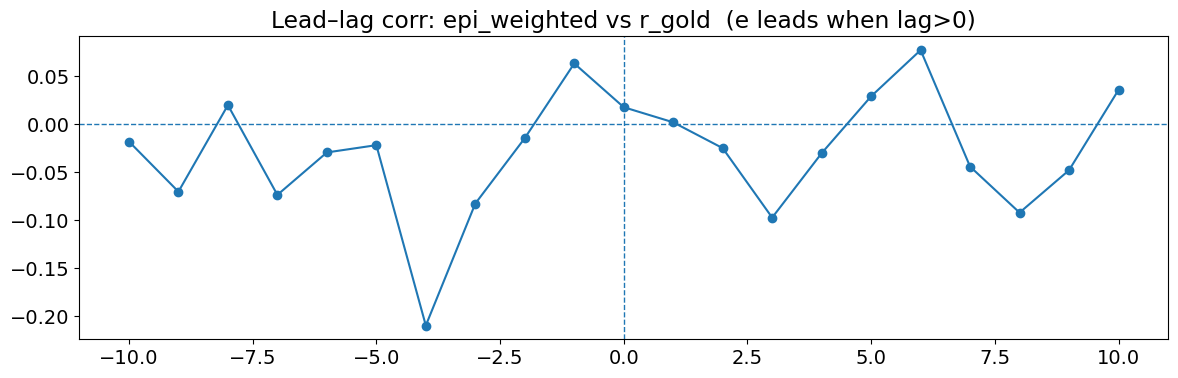

lag,-10,-9,-8,-7,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5,6,7,8,9,10
corr,0.104614,0.104349,0.139753,-0.012304,-0.013195,-0.005994,0.036104,0.081474,-0.093214,0.068122,-0.028793,0.084626,-0.008067,-0.073511,-0.011131,-0.228453,-0.004404,-0.029689,0.060596,0.019176,0.078283


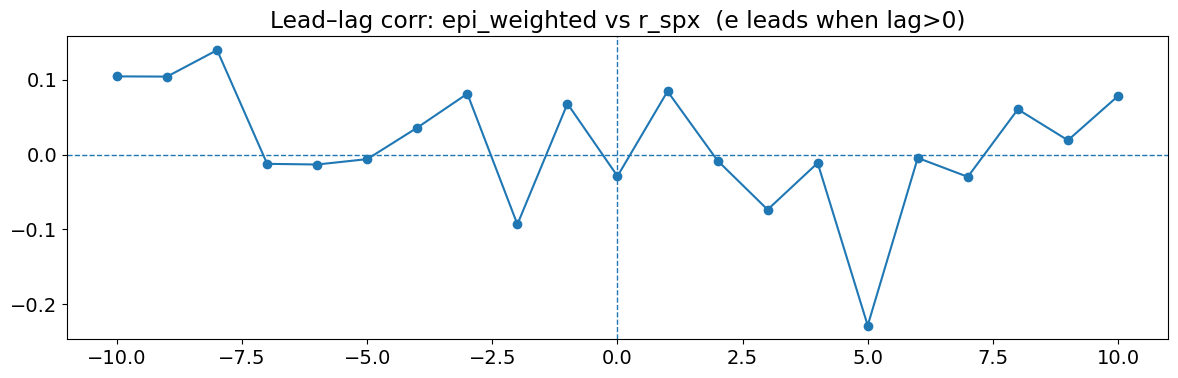

lag,-10,-9,-8,-7,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5,6,7,8,9,10
corr,-0.061656,-0.043153,-0.083026,-0.049681,-0.001183,0.141518,0.066485,-0.006184,0.018481,-0.069997,-0.042575,-0.053492,-0.012744,0.118302,-0.058702,-0.017963,0.015082,-0.123674,0.003453,0.073258,-0.036555


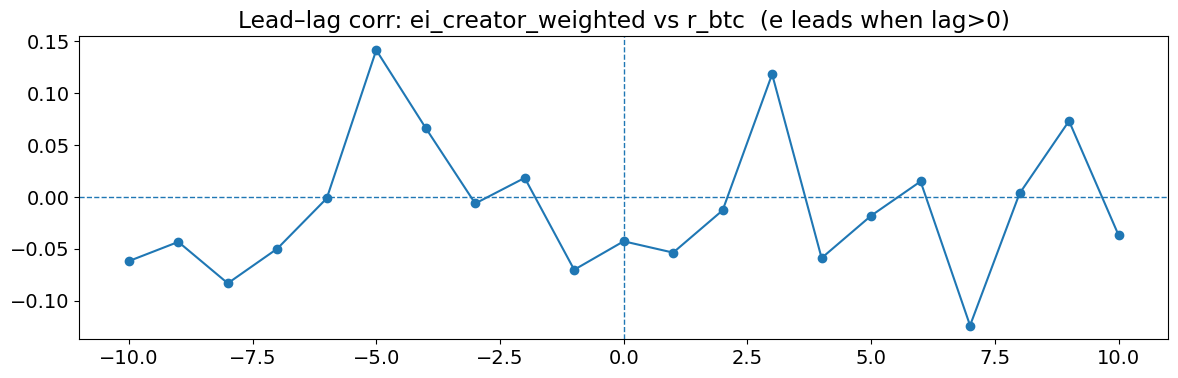

lag,-10,-9,-8,-7,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5,6,7,8,9,10
corr,-0.073082,-0.091904,-0.063142,0.069272,0.073235,0.154897,0.072141,0.052755,-0.00691,-0.064164,-0.087998,-0.124887,0.030994,-0.079338,0.128044,0.076422,-0.028652,-0.098849,-0.041223,0.010602,0.039922


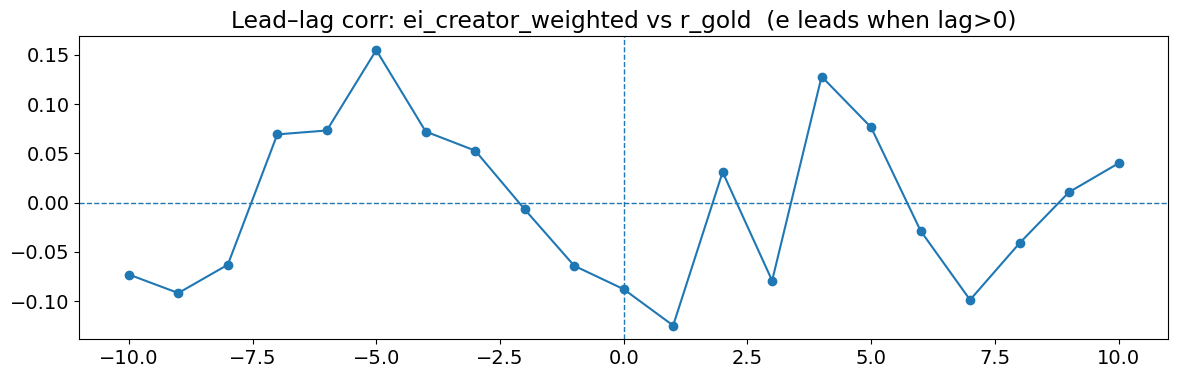

lag,-10,-9,-8,-7,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5,6,7,8,9,10
corr,-0.080187,0.055132,-0.031389,0.025615,0.080337,-0.087945,0.093446,-0.008846,0.163493,-0.15875,-0.110339,-0.09468,-0.084807,0.145943,0.034752,0.175184,-0.041904,-0.055379,-0.023356,0.132145,-0.058994


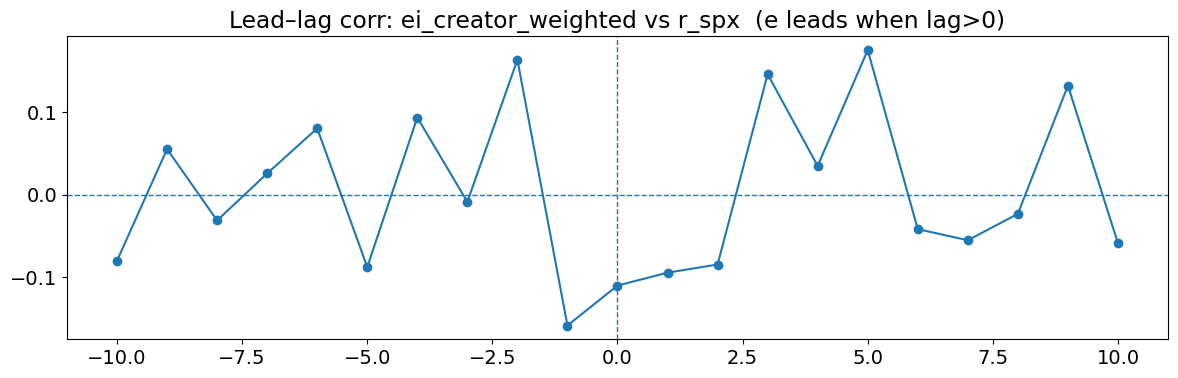

lag,-10,-9,-8,-7,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5,6,7,8,9,10
corr,-0.077621,-0.142801,-0.181449,-0.019143,-0.065199,-0.095734,0.012479,-0.05431,0.106768,0.071501,0.082395,0.083513,0.018724,-0.054711,0.002762,0.042997,-0.129563,0.260687,0.047858,-0.058016,-0.069787


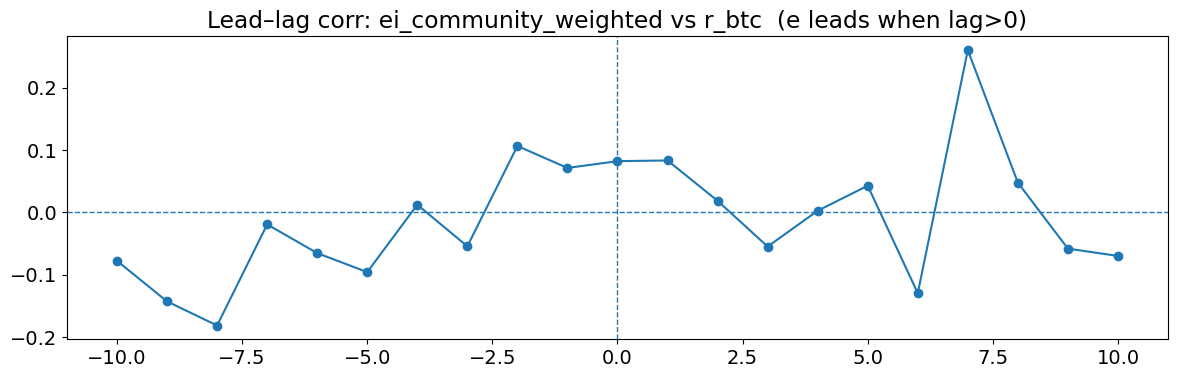

lag,-10,-9,-8,-7,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5,6,7,8,9,10
corr,-0.123438,0.098621,-0.064905,0.079435,0.030431,0.080202,0.084663,0.024692,0.119703,0.174879,0.009494,0.04467,-0.046274,-0.044711,-0.021754,0.132827,0.100973,-0.027311,0.090342,0.107572,-0.033743


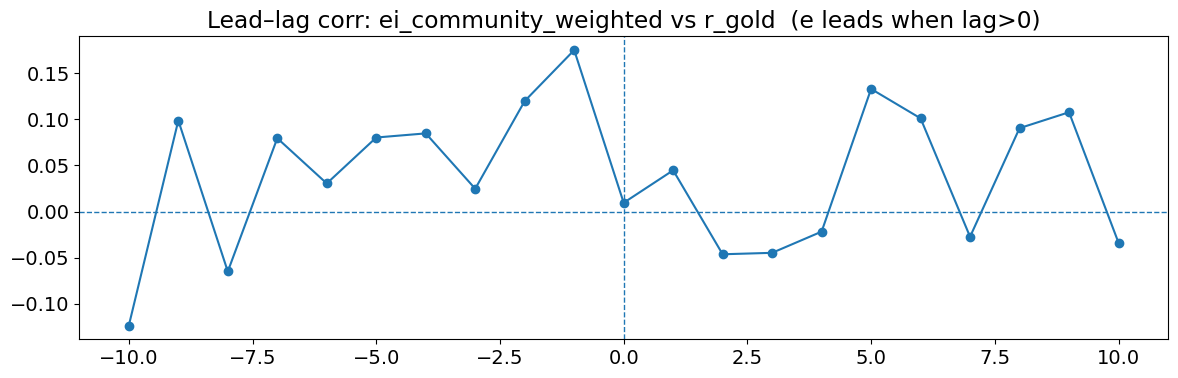

lag,-10,-9,-8,-7,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5,6,7,8,9,10
corr,-0.096586,-0.02709,-0.148855,0.016252,-0.137504,-0.146257,-0.075431,-0.002769,0.027732,-0.026265,0.105972,-0.024894,-0.010239,0.097306,-0.044582,0.020292,-0.176905,0.084841,0.052991,-0.029735,-0.067884


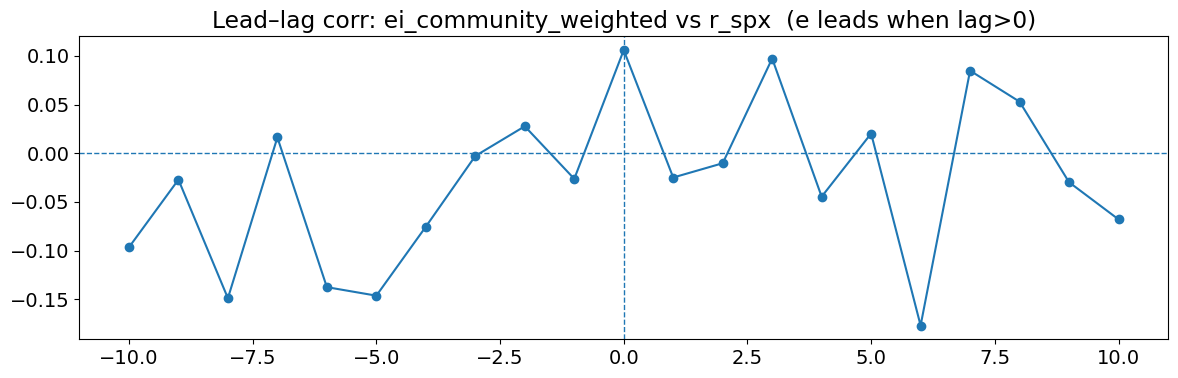

In [23]:
def lead_lag_corr(x: pd.Series, y: pd.Series, max_lag: int = 10):
    # corr between x(t-lag) and y(t)
    out = []
    for lag in range(-max_lag, max_lag + 1):
        if lag < 0:
            c = x.corr(y.shift(-lag))
        else:
            c = x.shift(lag).corr(y)
        out.append((lag, c))
    return pd.DataFrame(out, columns=["lag", "corr"]).set_index("lag")

MAX_LAG = 10
for e in EMO:
    for a in ASSETS:
        ll = lead_lag_corr(df1[e], df1[a], MAX_LAG)
        display(ll.T)

        plt.figure(figsize=(12, 4))
        plt.plot(ll.index, ll["corr"], marker="o")
        plt.axhline(0, linestyle="--", linewidth=1)
        plt.axvline(0, linestyle="--", linewidth=1)
        plt.title(f"Lead–lag corr: {e} vs {a}  (e leads when lag>0)")
        plt.tight_layout()
        plt.show()


### Simple predictive “beta” regressions (rolling OLS)
When emotion changes, how does the sensitivity of asset returns change?

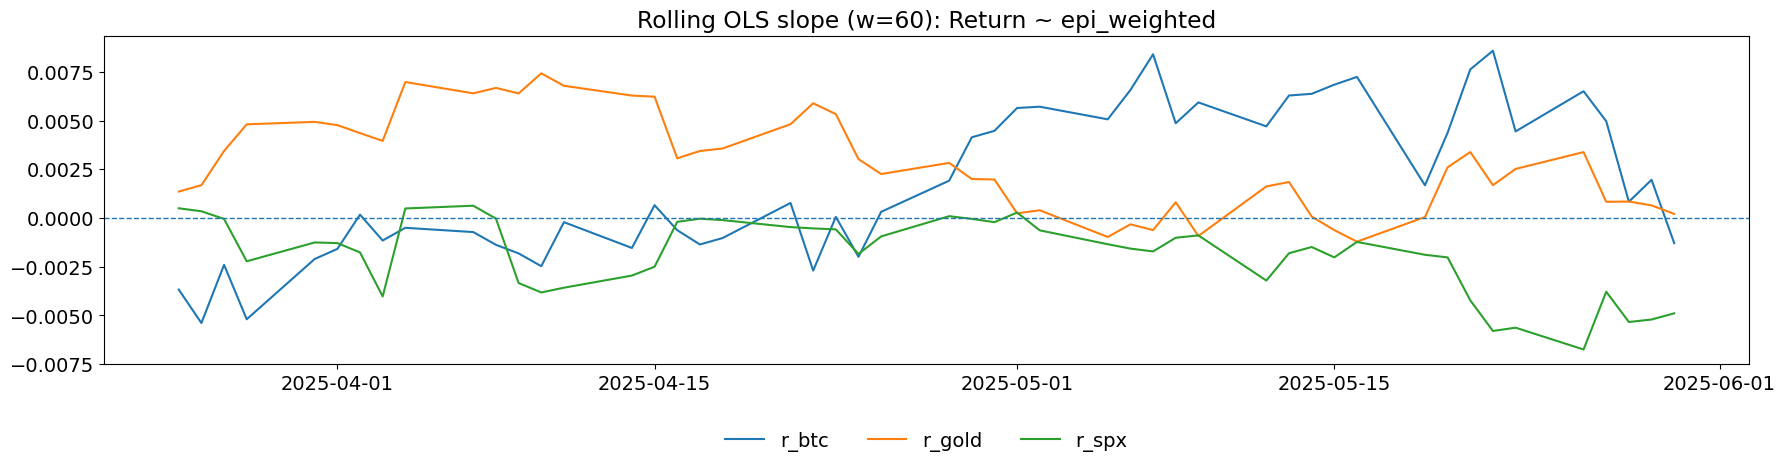

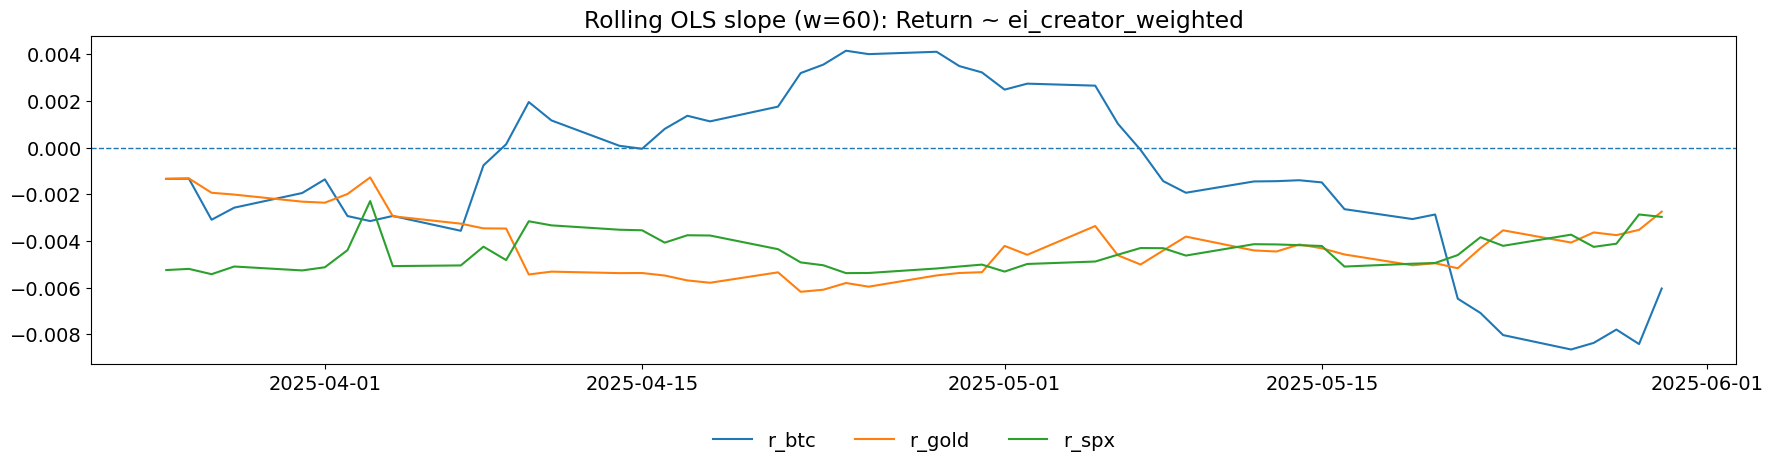

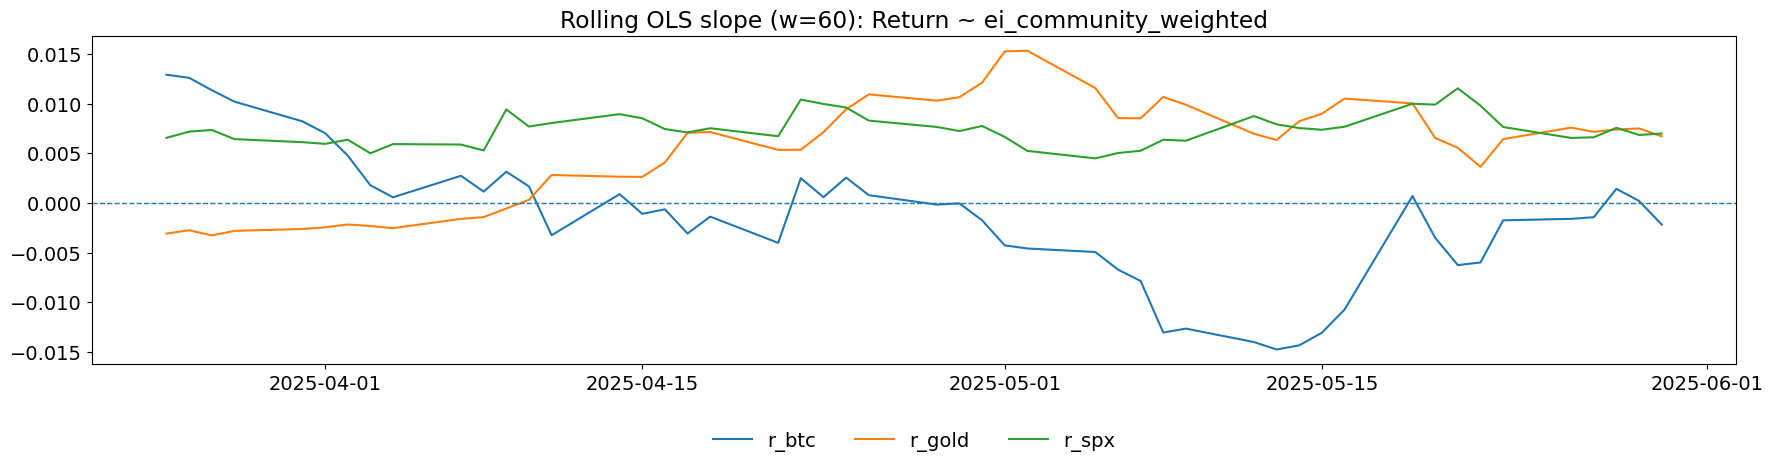

In [24]:
import statsmodels.api as sm

def rolling_beta(y: pd.Series, x: pd.Series, window: int = 60):
    betas = []
    idx = y.index
    for i in range(window, len(idx) + 1):
        ys = y.iloc[i-window:i]
        xs = x.iloc[i-window:i]
        tmp = pd.concat([ys, xs], axis=1).dropna()
        if len(tmp) < window * 0.7:
            betas.append(np.nan)
            continue
        Y = tmp.iloc[:, 0]
        X = sm.add_constant(tmp.iloc[:, 1])
        model = sm.OLS(Y, X).fit()
        betas.append(model.params.iloc[1])
    return pd.Series(betas, index=idx[window-1:])

W = 60  # try 30/60 depending on sample length
for e in EMO:
    plt.figure(figsize=(18, 5))
    for a in ASSETS:
        b = rolling_beta(df1[a], df1[e], window=W)
        plt.plot(b.index, b.values, label=a)
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title(f"Rolling OLS slope (w={W}): Return ~ {e}")
    plt.legend(ncol=3, frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.15))
    plt.tight_layout()
    plt.show()


### “Risk-off index” and substitution (SPX vs Gold vs BTC)
Emotional discourse intensifies under risk-off market conditions, particularly at the community level.

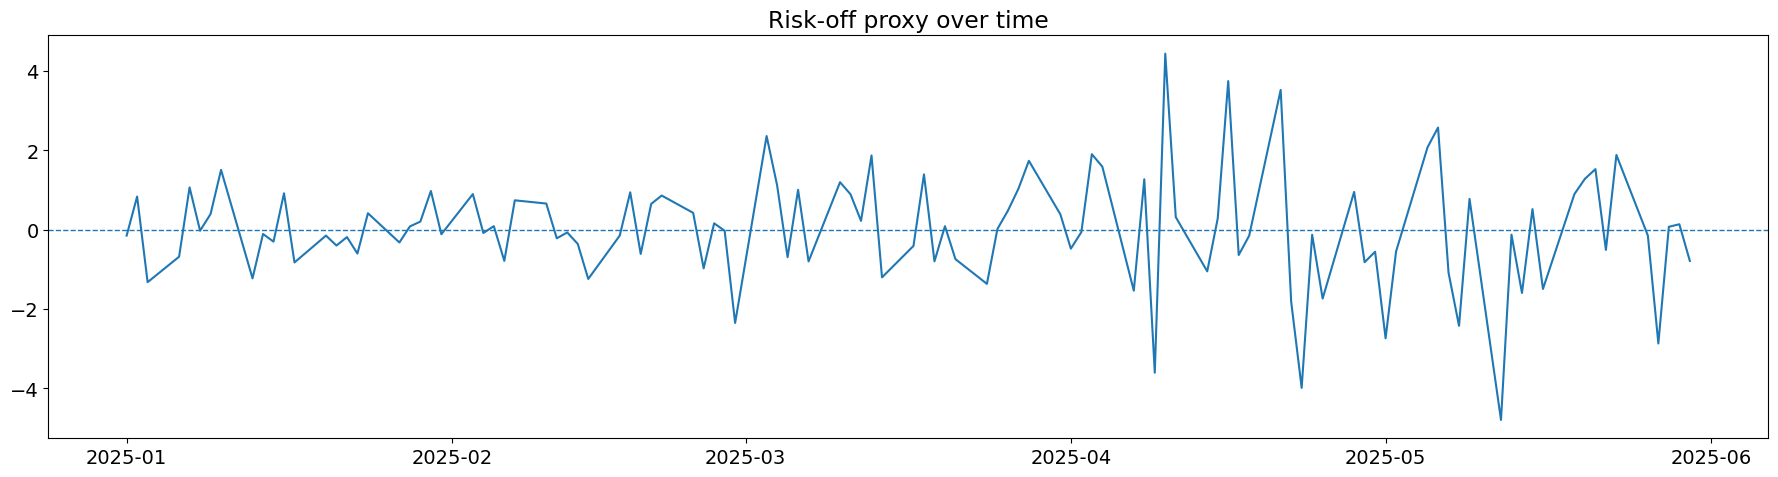

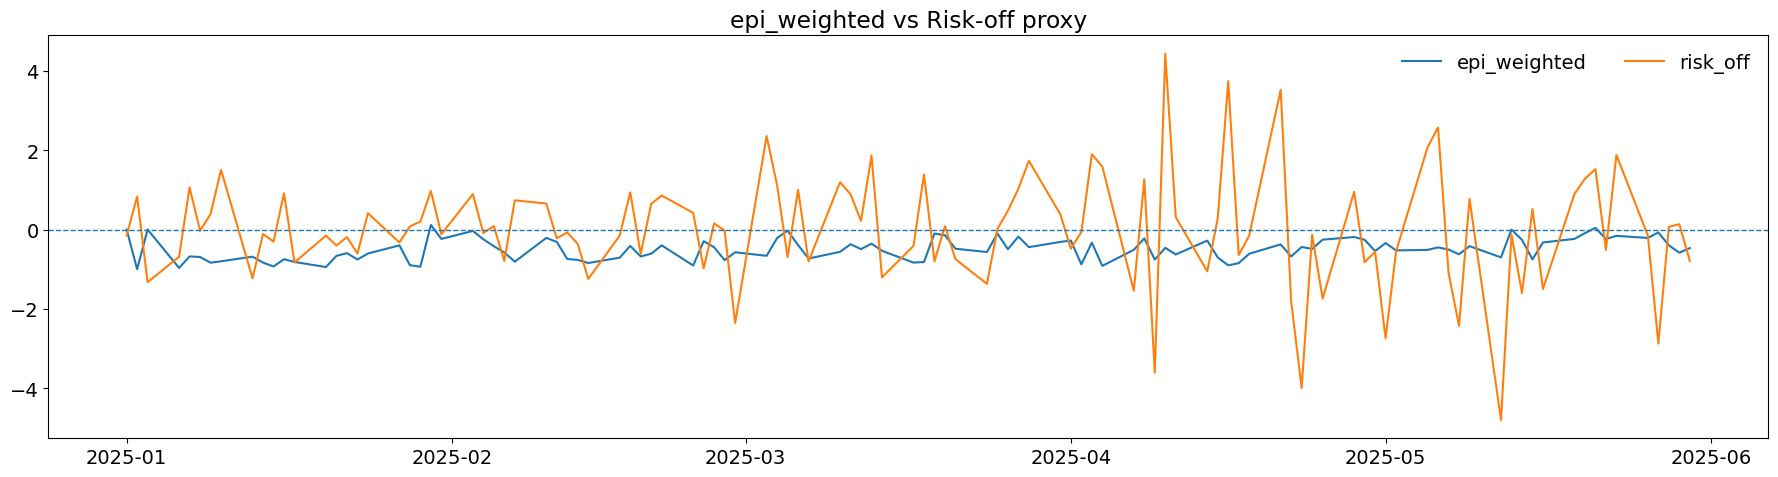

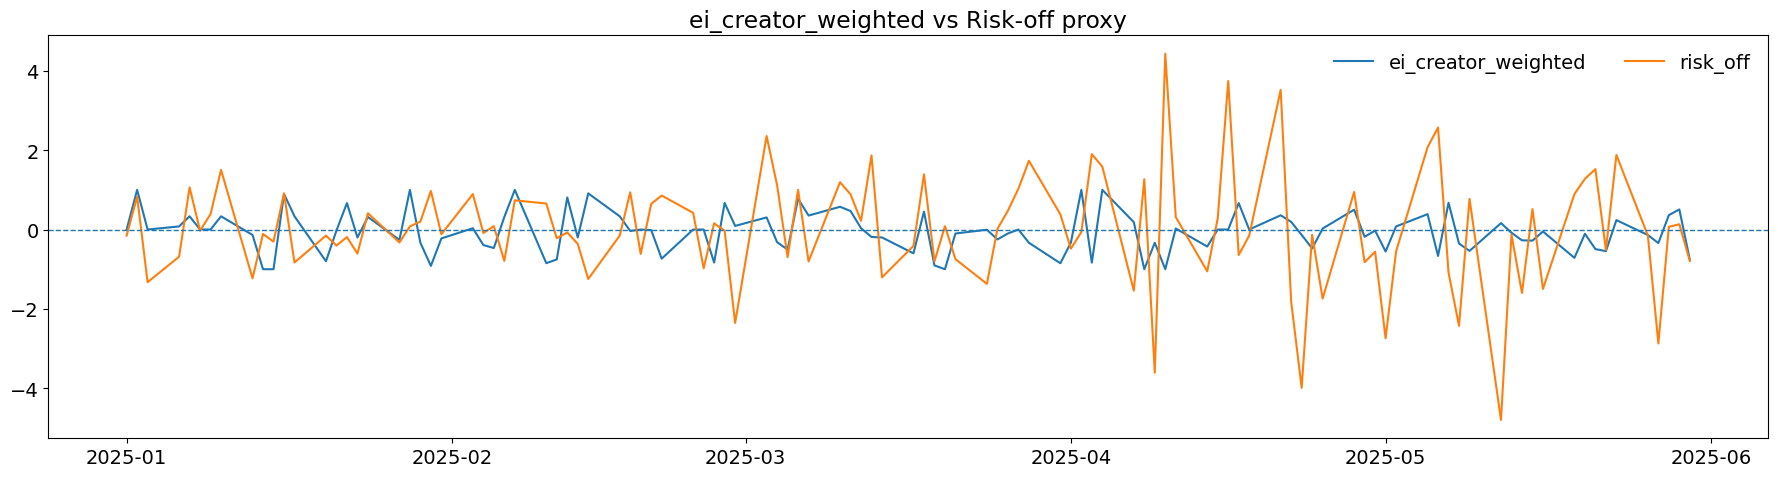

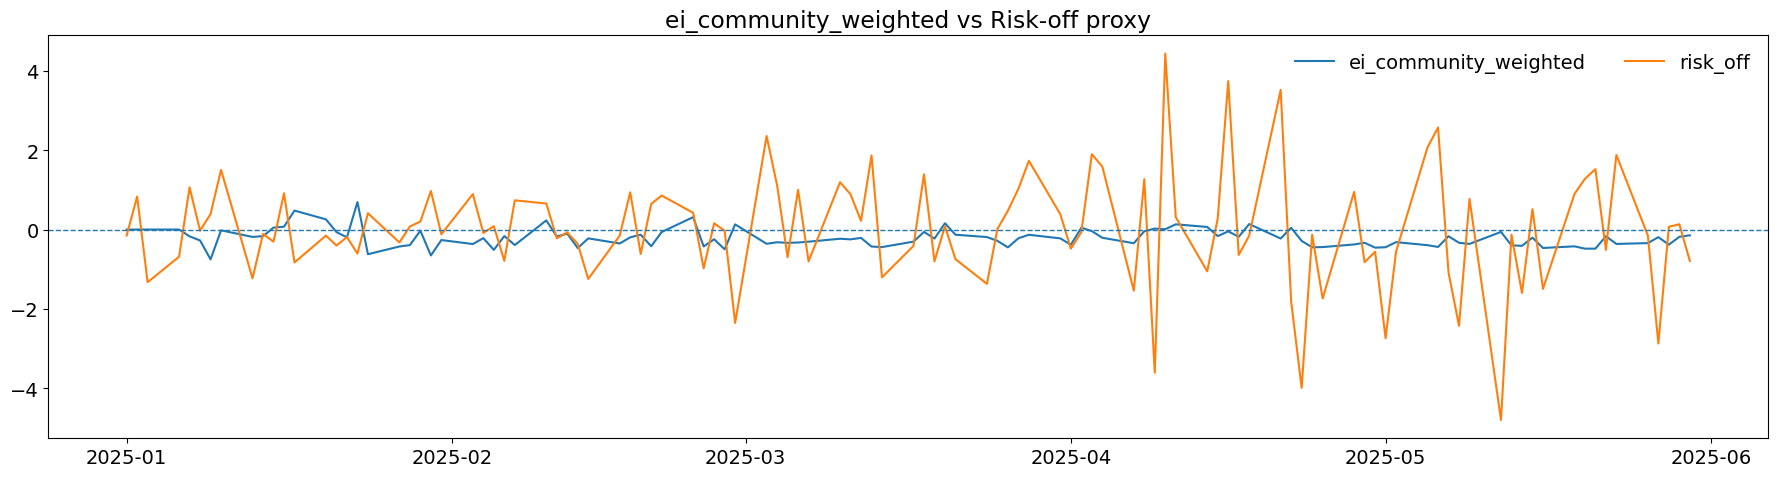

,risk_off
epi_weighted,0.032740
ei_creator_weighted,0.015659
ei_community_weighted,-0.067623


In [27]:
# Simple risk-off proxy: gold up & spx down (z-scored)
def z(s): 
    return (s - s.mean()) / s.std()

if "r_gold" in df1.columns and "r_spx" in df1.columns:
    df1["risk_off"] = z(df1["r_gold"]) - z(df1["r_spx"])
    plt.figure(figsize=(18, 5))
    plt.plot(df1.index, df1["risk_off"], label="risk_off = z(gold) - z(spx)")
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title("Risk-off proxy over time")
    plt.tight_layout()
    plt.show()

    for e in EMO:
        if e in df1.columns:
            plt.figure(figsize=(18, 5))
            plt.plot(df1.index, df1[e], label=e)
            plt.plot(df1.index, df1["risk_off"], label="risk_off")
            plt.axhline(0, linestyle="--", linewidth=1)
            plt.title(f"{e} vs Risk-off proxy")
            plt.legend(ncol=2, frameon=False)
            plt.tight_layout()
            plt.show()

    display(df1[["risk_off"] + EMO].corr().loc[EMO, ["risk_off"]])


### High–low EI/EPI days: do assets behave differently?


Average returns by epi_weighted quintile:


/var/folders/pr/x4pd5c4d2y94knncdskg53qm0000gn/T/ipykernel_77132/237981013.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = tmp.groupby("bucket")[returns.columns].mean()


,r_btc,r_gold,r_spx
bucket,,,
Q1,0.007577,0.003935,0.000529
Q2,0.005778,0.000612,0.003483
Q3,-0.010958,0.001488,0.000836
Q4,-0.002437,-0.001547,-0.004824
Q5,0.005064,0.005645,0.000146


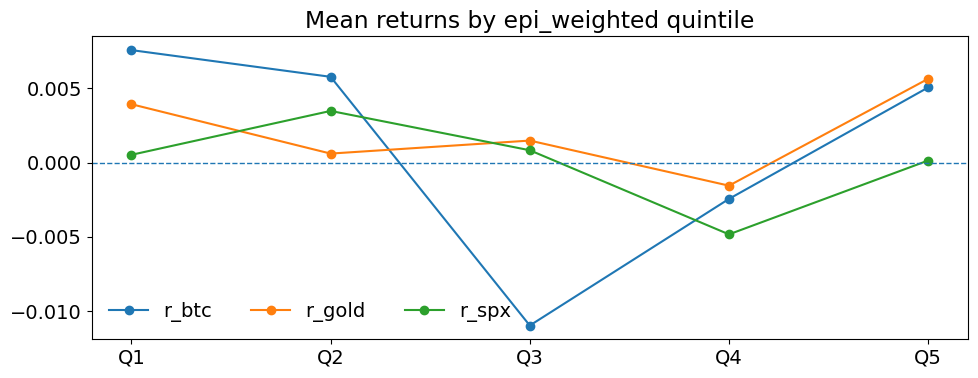


Average returns by ei_creator_weighted quintile:


/var/folders/pr/x4pd5c4d2y94knncdskg53qm0000gn/T/ipykernel_77132/237981013.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = tmp.groupby("bucket")[returns.columns].mean()


,r_btc,r_gold,r_spx
bucket,,,
Q1,-0.000013,0.004862,-0.002563
Q2,0.005056,0.001662,0.005537
Q3,0.000829,0.000346,0.001147
Q4,0.005023,0.000474,0.004024
Q5,-0.004994,0.002946,-0.007087


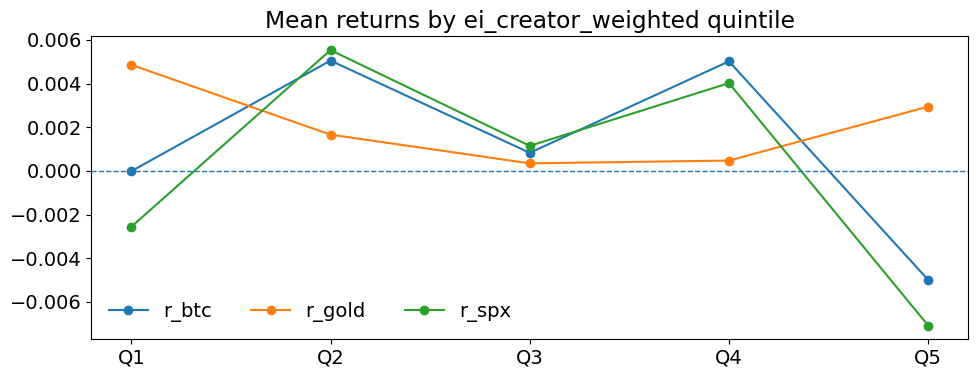


Average returns by ei_community_weighted quintile:


/var/folders/pr/x4pd5c4d2y94knncdskg53qm0000gn/T/ipykernel_77132/237981013.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = tmp.groupby("bucket")[returns.columns].mean()


,r_btc,r_gold,r_spx
bucket,,,
Q1,0.001445,0.001583,-0.000502
Q2,-0.000713,0.003746,-0.001112
Q3,-0.002998,0.000041,-0.001014
Q4,-0.004390,-0.000650,-0.004445
Q5,0.011297,0.005597,0.007052


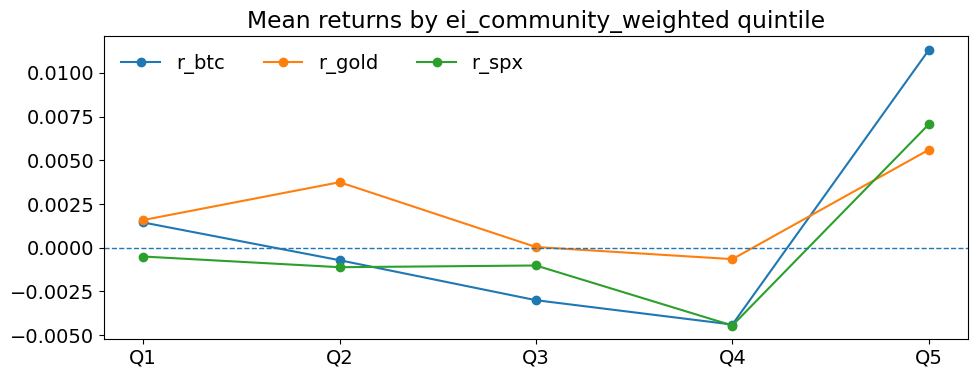

In [25]:
def quantile_return_table(signal: pd.Series, returns: pd.DataFrame, q=5):
    tmp = pd.concat([signal.rename("signal"), returns], axis=1).dropna()
    tmp["bucket"] = pd.qcut(tmp["signal"], q=q, labels=[f"Q{i+1}" for i in range(q)])
    out = tmp.groupby("bucket")[returns.columns].mean()
    return out

RET = df1[ASSETS]
for e in EMO:
    tbl = quantile_return_table(df1[e], RET, q=5)
    print(f"\nAverage returns by {e} quintile:")
    display(tbl)

    # simple plot
    plt.figure(figsize=(10, 4))
    for a in ASSETS:
        plt.plot(tbl.index, tbl[a], marker="o", label=a)
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title(f"Mean returns by {e} quintile")
    plt.legend(ncol=3, frameon=False)
    plt.tight_layout()
    plt.show()


### Event-window asset reaction table
Asset reactions during tariff escalation and relaxation phases align with shifts in emotional discourse, suggesting that emotional narratives co-evolve with policy-driven market uncertainty.

In [26]:
EVENT_WINDOWS = [
    ("Initial Tariff Announcements", "2025-01-20", "2025-01-26"),
    ("Tariffs Postponed", "2025-03-04", "2025-03-06"),
    ("China Retaliation & US Tariffs Imposed", "2025-03-10", "2025-03-13"),
    ("Global Tariffs & China Retaliation", "2025-04-02", "2025-04-06"),
    ("US-China Tariff Threats", "2025-04-09", "2025-04-12"),
    ("Tariffs Relaxed", "2025-04-27", "2025-05-04"),
    ("Trade Deals & US-China Tariff Rollbacks", "2025-05-05", "2025-05-14"),
    ("Non-US Manufactured Apple Tariff Threat", "2025-05-20", "2025-05-25"),
]

PRE_DAYS, POST_DAYS = 7, 7
rows = []
for name, s, e in EVENT_WINDOWS:
    s, e = pd.to_datetime(s), pd.to_datetime(e)

    pre = df1.loc[(df1.index >= s - pd.Timedelta(days=PRE_DAYS)) & (df1.index < s), ASSETS]
    dur = df1.loc[(df1.index >= s) & (df1.index <= e), ASSETS]
    post = df1.loc[(df1.index > e) & (df1.index <= e + pd.Timedelta(days=POST_DAYS)), ASSETS]

    rows.append({"event": name, "phase": "pre", "n": len(pre), **pre.mean().to_dict()})
    rows.append({"event": name, "phase": "during", "n": len(dur), **dur.mean().to_dict()})
    rows.append({"event": name, "phase": "post", "n": len(post), **post.mean().to_dict()})
    rows.append({"event": name, "phase": "during-pre", "n": np.nan, **(dur.mean() - pre.mean()).to_dict()})
    rows.append({"event": name, "phase": "post-during", "n": np.nan, **(post.mean() - dur.mean()).to_dict()})

event_asset_tbl = pd.DataFrame(rows)
display(event_asset_tbl)


,event,phase,n,r_btc,r_gold,r_spx
0,Initial Tariff Announcements,pre,5.0,0.019619,0.002626,0.005739
1,Initial Tariff Announcements,during,5.0,0.000683,0.002391,0.003458
2,Initial Tariff Announcements,post,5.0,-0.004661,0.002519,-0.002000
3,Initial Tariff Announcements,during-pre,NaN,-0.018936,-0.000236,-0.002281
4,Initial Tariff Announcements,post-during,NaN,-0.005344,0.000128,-0.005458
5,Tariffs Postponed,pre,5.0,-0.012067,-0.003953,-0.004514
6,Tariffs Postponed,during,3.0,0.014758,0.003031,-0.006397
7,Tariffs Postponed,post,5.0,-0.020822,0.004589,-0.007710
8,Tariffs Postponed,during-pre,NaN,0.026825,0.006984,-0.001883
9,Tariffs Postponed,post-during,NaN,-0.035580,0.001558,-0.001312
